# Imports

In [1]:
from math import*
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import casadi
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.kernel_ridge import KernelRidge
import itertools
from scipy import stats
from sklearn.model_selection import train_test_split, KFold

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.utils.validation import check_is_fitted
from cvxopt import matrix, solvers
from KLIEP_importance_estimation import KLIEP_importance_estimation
import United_function_tools as uft
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.linear_model import Ridge

from ucimlrepo import fetch_ucirepo

from rkhs_glm_scaled import RKHSGLM_Scaled, sigmoid, KERNELS

from pseudo_label_experiment_general import FAMILIES, make_data, mean, KGLM_covariate_shift, a_logpartition, run_experiment

import time
from tqdm import tqdm

from dataclasses import dataclass, field
from typing import Dict, Any, List, Tuple, Optional, Union, Callable, Type, Generic, TypeVar
from joblib import Parallel, delayed

# Utils

In [2]:
def evaluate_binary(y_true, p, thr=0.5, prefix=""):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)
    yhat = (p >= thr).astype(int)
    out = {
        f"{prefix}acc": accuracy_score(y_true, yhat),
        f"{prefix}bal_acc": balanced_accuracy_score(y_true, yhat),
        f"{prefix}auc": roc_auc_score(y_true, p),
        f"{prefix}logloss": log_loss(y_true, p),
        f"{prefix}pos_rate": float(np.mean(y_true))
    }
    return out

def pretty_print_metrics(m):
    keys = list(m.keys())
    maxk = max(len(k) for k in keys)
    for k in sorted(keys):
        v = m[k]
        if isinstance(v, float):
            print(f"{k:<{maxk}} : {v:.4f}")
        else:
            print(f"{k:<{maxk}} : {v}")

    
def _sigmoid(z):
    z = np.asarray(z)
    return 1.0 / (1.0 + np.exp(-z))

def _soft_logistic_risk_from_f(alog, f, p_soft_or_y):
    """
    risk = E[ alog(f) - y f ] where y can be hard {0,1} or soft in [0,1].
    """
    return float(np.mean(alog(f) - p_soft_or_y * f))

def _metrics_from_scores(y_true, f, compute_auc=True):
    """
    Given true labels y and decision scores f, compute:
    acc, bal_acc, risk (caller computed), auc/logloss if requested.
    """
    y_true = y_true.astype(int)
    p = _sigmoid(f)
    y_pred = (p >= 0.5).astype(int)

    out = {
        "acc": float(accuracy_score(y_true, y_pred)),
        "bal_acc": float(balanced_accuracy_score(y_true, y_pred)),
    }
    if compute_auc:
        # AUC undefined if only one class in y_true
        if np.all(y_true == y_true[0]):
            out["auc"] = np.nan
            out["logloss_sklearn"] = np.nan
        else:
            out["auc"] = float(roc_auc_score(y_true, p))
            out["logloss_sklearn"] = float(log_loss(y_true, np.clip(p, 1e-15, 1 - 1e-15)))
    return out


def _keys_for_candidate_key(candidate_key: str) -> set:
    return {
        "klr":       {"klr_soft"},
        "krr":       {"krr"},
        "kliep_klr": {"kliep_w_cand", "kliep_w_imp"},
        "kmm_klr":   {"kmm_w_cand",   "kmm_w_imp"},
    }.get(candidate_key, set())

In [3]:
# ID / OOD split

def split_id_ood(x, y, le=3, seed=1):
    n=y.shape[0]
    rng = np.random.default_rng(seed)
    p=(x[:,0]-x[:,0].min())**2/le
    p=np.clip(p,a_max=1,a_min=0)


    # Splitting into training data and test data
    x_train=[]
    y_train=[]
    x_test=[]
    y_test=[]

    s = rng.binomial(1,p,p.shape[0])
    for k in range(n):
        if s[k]==0:
            x_train.append(x[k,:])
            y_train.append(y[k])
        else:
            x_test.append(x[k,:])
            y_test.append(y[k])

    x_train=np.array(x_train)
    y_train=np.array(y_train)

    x_test=np.array(x_test)
    y_test=np.array(y_test)

    return x_train, y_train, x_test, y_test

In [4]:
# ----------------------------
# Core stats helpers
# ----------------------------
def _t_ci_mean(arr, alpha=0.05):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    n = len(arr)
    m = float(arr.mean())
    s = float(arr.std(ddof=1))
    se = s / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    return m, (m - tcrit*se, m + tcrit*se), se

def _paired_diff(A, B):
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    mask = np.isfinite(A) & np.isfinite(B)
    return A[mask] - B[mask]

def paired_tests(diffs, name, alternative="less", alpha=0.05, B=20000, boot_seed=0):
    """
    diffs: per-seed paired differences (A - B) for metric.
    alternative:
      - "less" means H1: mean(diffs) < 0 (A better if lower is better)
      - "greater" means H1: mean(diffs) > 0
      - "two-sided"
    """
    diffs = np.asarray(diffs, float)
    diffs = diffs[np.isfinite(diffs)]
    S = len(diffs)
    if S < 5:
        raise ValueError(f"Too few seeds after filtering: {S}")

    mean_diff = float(diffs.mean())
    sd = float(diffs.std(ddof=1))
    se = sd / np.sqrt(S)
    t_stat, p_two = stats.ttest_1samp(diffs, 0.0)

    if alternative == "two-sided":
        p_t = float(p_two)
    elif alternative == "less":
        p_t = float(p_two/2) if t_stat < 0 else float(1 - p_two/2)
    elif alternative == "greater":
        p_t = float(p_two/2) if t_stat > 0 else float(1 - p_two/2)
    else:
        raise ValueError("alternative must be one of {'less','greater','two-sided'}")

    tcrit = stats.t.ppf(1 - alpha/2, df=S-1)
    ci_t = (mean_diff - tcrit*se, mean_diff + tcrit*se)

    # Wilcoxon signed-rank
    try:
        w_stat, p_w = stats.wilcoxon(diffs, alternative=alternative, zero_method="wilcox")
        w_stat, p_w = float(w_stat), float(p_w)
    except Exception:
        w_stat, p_w = np.nan, np.nan

    # Sign test
    eps = 1e-12
    if alternative == "less":
        wins = int(np.sum(diffs < -eps))
        ties = int(np.sum(np.abs(diffs) <= eps))
        n_eff = int(S - ties)
        p_sign = float(stats.binomtest(wins, n_eff, p=0.5, alternative="greater").pvalue) if n_eff > 0 else np.nan
    elif alternative == "greater":
        wins = int(np.sum(diffs > eps))
        ties = int(np.sum(np.abs(diffs) <= eps))
        n_eff = int(S - ties)
        p_sign = float(stats.binomtest(wins, n_eff, p=0.5, alternative="greater").pvalue) if n_eff > 0 else np.nan
    else:
        wins = int(np.sum(diffs < -eps))
        ties = int(np.sum(np.abs(diffs) <= eps))
        n_eff = int(S - ties)
        p_sign = float(stats.binomtest(wins, n_eff, p=0.5, alternative="two-sided").pvalue) if n_eff > 0 else np.nan

    # Bootstrap CI over seeds
    rng = np.random.default_rng(boot_seed)
    boot_means = np.empty(B, float)
    for b in range(B):
        bs = rng.integers(0, S, size=S)
        boot_means[b] = diffs[bs].mean()
    ci_boot = (float(np.quantile(boot_means, alpha/2)), float(np.quantile(boot_means, 1-alpha/2)))
    if alternative == "less":
        p_boot = float(np.mean(boot_means >= 0.0))
    elif alternative == "greater":
        p_boot = float(np.mean(boot_means <= 0.0))
    else:
        p_boot = float(2 * min(np.mean(boot_means <= 0.0), np.mean(boot_means >= 0.0)))

    return {
        "name": name,
        "n_seeds": S,
        "mean": mean_diff,
        "sd": sd,
        "se": se,
        "ci_t": tuple(map(float, ci_t)),
        "t": float(t_stat),
        "p_t": float(p_t),
        "w": float(w_stat),
        "p_w": float(p_w),
        "wins": wins,
        "losses": int(S - ties - wins),
        "ties": ties,
        "p_sign": float(p_sign),
        "ci_boot": ci_boot,
        "p_boot": float(p_boot),
    }

def print_paired_test(res, digits=6):
    lo, hi = res["ci_t"]
    blo, bhi = res["ci_boot"]
    print(f"\n=== {res['name']} ===")
    print(f"n_seeds = {res['n_seeds']}")
    print(f"mean(A-B) = {res['mean']:.{digits}g}   sd = {res['sd']:.{digits}g}   se = {res['se']:.{digits}g}")
    print(f"95% t-CI for mean: [{lo:.{digits}g}, {hi:.{digits}g}]")
    print(f"t-test: t={res['t']:.{digits}g}, p={res['p_t']:.{digits}g}")
    print(f"Wilcoxon: W={res['w']:.{digits}g}, p={res['p_w']:.{digits}g}")
    print(f"Sign test: wins/losses/ties = {res['wins']}/{res['losses']}/{res['ties']}  p={res['p_sign']:.{digits}g}")
    print(f"Bootstrap CI (mean): [{blo:.{digits}g}, {bhi:.{digits}g}]  p={res['p_boot']:.{digits}g}")

def summarize_distribution(diffs, name):
    diffs = np.asarray(diffs, float)
    diffs = diffs[np.isfinite(diffs)]
    q = np.quantile(diffs, [0.10, 0.25, 0.50, 0.75, 0.90])
    eps = 1e-12
    wins = int(np.sum(diffs < -eps))
    losses = int(np.sum(diffs > eps))
    ties = int(np.sum(np.abs(diffs) <= eps))
    print(f"\n{name}")
    print(f" mean  : {diffs.mean()}")
    print(f" median: {np.median(diffs)}")
    print(f" 10/25/50/75/90%: {q}")
    print(f" wins/losses/ties: {wins}/{losses}/{ties} (wins fraction among non-ties: {wins/(wins+losses+1e-12):.3f})")


# ----------------------------
# Shift diagnostics (per seed)
# ----------------------------
def domain_clf_auc(X_id, X_ood, seed):
    """
    Domain classifier AUC: how separable ID vs OOD covariates are.
    Higher => bigger covariate shift.
    """
    X_id = np.asarray(X_id)
    X_ood = np.asarray(X_ood)
    X = np.vstack([X_id, X_ood])
    y = np.concatenate([np.zeros(len(X_id), int), np.ones(len(X_ood), int)])
    # simple logistic domain classifier
    clf = LogisticRegression(max_iter=5000, random_state=seed)
    clf.fit(X, y)
    p = clf.predict_proba(X)[:, 1]
    return float(roc_auc_score(y, p))

def smd_per_feature(X_id, X_ood):
    """
    Standardized mean difference per feature.
    """
    X_id = np.asarray(X_id, float)
    X_ood = np.asarray(X_ood, float)
    mu1 = X_id.mean(axis=0)
    mu0 = X_ood.mean(axis=0)
    v1 = X_id.var(axis=0, ddof=1)
    v0 = X_ood.var(axis=0, ddof=1)
    denom = np.sqrt(0.5*(v1+v0) + 1e-12)
    return (mu1 - mu0) / denom

In [5]:
def compute_kmm_weights_rbf(X_source, X_target, gamma=None, B=3.0, epsilon=None):
    """
    Computes Kernel Mean Matching (KMM) weights using a Gaussian RBF kernel.
    B is lowered to 3.0 to prevent numerical explosions in downstream solvers.
    """
    ns = X_source.shape[0]
    nt = X_target.shape[0]
    
    if epsilon is None:
        epsilon = (np.sqrt(ns) - 1) / np.sqrt(ns)
        
    # Compute RBF kernel matrices
    K_ss = rbf_kernel(X_source, X_source, gamma=gamma)
    K_st = rbf_kernel(X_source, X_target, gamma=gamma)
    
    kappa = np.sum(K_st, axis=1) * (ns / nt)
    
    P = matrix(K_ss + 1e-6 * np.eye(ns), tc='d')
    q = matrix(-kappa, tc='d')
    
    G = np.vstack([
        -np.eye(ns),
        np.eye(ns),
        np.ones((1, ns)),
        -np.ones((1, ns))
    ])
    
    h = np.hstack([
        np.zeros(ns),
        np.ones(ns) * B,
        [ns * (1 + epsilon)],
        [-ns * (1 - epsilon)]
    ])
    
    G = matrix(G, tc='d')
    h = matrix(h, tc='d')
    
    solvers.options['show_progress'] = False
    
    try:
        sol = solvers.qp(P, q, G, h)
        beta = np.array(sol['x']).flatten()
    except ValueError:
        print("Warning: CVXOPT solver failed, falling back to uniform weights.")
        beta = np.ones(ns)
        
    return np.clip(beta, 0, B)

# Data loading, preprocessing (0/1), and visualization of the shift

In [6]:
# Load the raisin dataset and preprocess it
  
# fetch dataset 
raisin = fetch_ucirepo(id=850) 
  
# data (as pandas dataframes) 
X = raisin.data.features 
y_tot = raisin.data.targets 

# Convert to numpy arrays
x_tot = X.to_numpy()
y_tot = y_tot.to_numpy().ravel()

# Binary encode y
y_tot = np.where(y_tot == 'Kecimen', 1, 0)

# Scale the data
x_tot=(x_tot-x_tot.mean(axis=0))/x_tot.std(axis=0)
n=y_tot.shape[0]

y_tot=y_tot.astype(np.double)

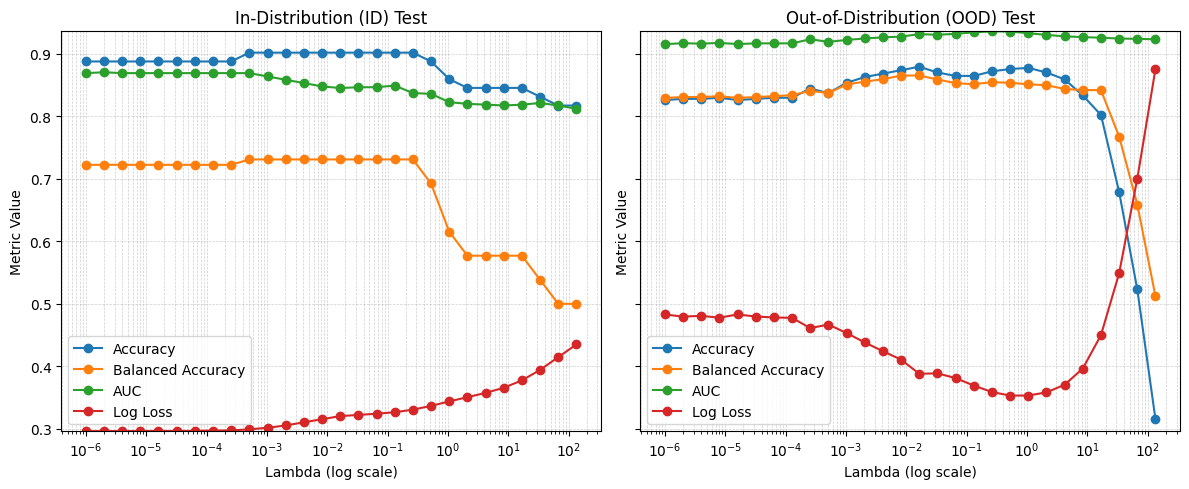

In [7]:
# Visualize the shift
x_train, y_train, x_test, y_test = split_id_ood(x_tot, y_tot, seed=122)
X_id_tr, X_id_te, y_id_tr, y_id_te = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=0)

beta = 2
lbd_min, lbd_max = 1e-6, 100
m = int(np.ceil(np.log(lbd_max / lbd_min) / np.log(beta))) + 1
Lambda = lbd_min * (beta ** np.arange(m))
ml = len(Lambda)
n_1 = X_id_tr.shape[0]
Xl = np.arange(ml)
acc_list_id, auc_list_id, log_list_id, bal_acc_list_id = [], [], [], []
acc_list_ood, auc_list_ood, log_list_ood, bal_acc_list_ood = [], [], [], []

for lbd in Lambda:
    clf = LogisticRegression(max_iter=5000, C=1/(lbd)).fit(X_id_tr, y_id_tr)
    p_id_te = clf.predict_proba(X_id_te)[:, 1]
    p_ood = clf.predict_proba(x_test)[:, 1]

    #print("\n=== Performance of ID-trained model ===")
    m_id = evaluate_binary(y_id_te, p_id_te, prefix="IDtest_")
    m_ood = evaluate_binary(y_test, p_ood, prefix="OOD_")
    #pretty_print_metrics({**m_id, **m_ood})
    acc_list_id.append(m_id['IDtest_acc'])
    auc_list_id.append(m_id['IDtest_auc'])
    log_list_id.append(m_id['IDtest_logloss'])
    bal_acc_list_id.append(m_id['IDtest_bal_acc'])
    acc_list_ood.append(m_ood['OOD_acc'])
    auc_list_ood.append(m_ood['OOD_auc'])
    log_list_ood.append(m_ood['OOD_logloss'])
    bal_acc_list_ood.append(m_ood['OOD_bal_acc'])

# Prepare data for plotting
metrics_id = {
    'Accuracy': acc_list_id,
    'Balanced Accuracy': bal_acc_list_id,
    'AUC': auc_list_id,
    'Log Loss': log_list_id
}

metrics_ood = {
    'Accuracy': acc_list_ood,
    'Balanced Accuracy': bal_acc_list_ood,
    'AUC': auc_list_ood,
    'Log Loss': log_list_ood
}

metric_names = list(metrics_id.keys())
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# Figure out the full y-range to align both axes
all_vals = []
for vals in metrics_id.values():
    all_vals.extend(vals)
for vals in metrics_ood.values():
    all_vals.extend(vals)
y_min = min(all_vals)
y_max = max(all_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot ID metrics
ax = axes[0]
for metric, color in zip(metric_names, colors):
    ax.plot(Lambda, metrics_id[metric], marker='o', color=color, label=metric)
ax.set_xscale('log')
ax.set_xlabel('Lambda (log scale)')
ax.set_ylabel('Metric Value')
ax.set_title('In-Distribution (ID) Test')
ax.set_ylim([y_min, y_max])
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)

# Plot OOD metrics
ax = axes[1]
for metric, color in zip(metric_names, colors):
    ax.plot(Lambda, metrics_ood[metric], marker='o', color=color, label=metric)
ax.set_xscale('log')
ax.set_xlabel('Lambda (log scale)')
ax.set_ylabel('Metric Value')
ax.set_title('Out-of-Distribution (OOD) Test')
ax.set_ylim([y_min, y_max])
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)

fig.tight_layout()
plt.show()

# Main class

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Primitives
# ──────────────────────────────────────────────────────────────────────────────

@dataclass
class FoldContext:
    """
    Fold-level data available to imputers and fold_risk functions.

    Naming follows the paper's notation:
      D1  →  X_cand / y_cand  (val_idx fold  – used to train candidates)
      D2  →  X_imp  / y_imp   (train_idx fold – used to train imputers / validate naive)

    Imputers populate `pseudo` before the lambda loop.

    Standard keys:
      "klr_soft"     KLR soft probs on X0_sel              (pseudo-label)
      "krr"          KRR raw preds on X0_sel               (pseudo-label)
      "kliep_w_cand" KLIEP density ratios for X_cand       (IW)
      "kliep_w_imp"  KLIEP density ratios for X_imp        (IW)
      "kmm_w_cand"   KMM density ratios for X_cand         (IW)
      "kmm_w_imp"    KMM density ratios for X_imp          (IW)
    """
    X_cand: np.ndarray          # D1
    y_cand: np.ndarray
    X_imp:  np.ndarray          # D2
    y_imp:  np.ndarray
    X0_sel: np.ndarray
    y0_sel: np.ndarray
    pseudo: Dict[str, np.ndarray] = field(default_factory=dict)


@dataclass
class MethodSpec:
    """
    fit_candidate : (X, y, lbd, ctx) -> model
        ctx is passed so IW methods can pull sample weights from ctx.pseudo.
        Unweighted methods (naive, pseudo, oracle) simply ignore ctx.
    fold_risk     : (model, ctx) -> float
    get_scores    : (model, X)   -> 1-D np.ndarray   (for final evaluation)
    """
    name:          str
    candidate_key: str
    fit_candidate: Callable   # (X, y, lbd, ctx) -> model
    fold_risk:     Callable   # (model, ctx) -> float
    get_scores:    Callable   # (model, X) -> np.ndarray


# ──────────────────────────────────────────────────────────────────────────────
# Main class   (only the changed / new methods shown; everything else unchanged)
# ──────────────────────────────────────────────────────────────────────────────

class sk_log_covariate_shift_new:
    """
    OOD model selection via pseudo-labeling / importance weighting.

    Methods and imputers are registered before fit() is called.
    If nothing is registered, _build_default_methods() is called automatically,
    reproducing the original 5-method behaviour.

    Inputs
    ------
    ID  : (X,  y)  labeled source
    OOD : (X0, y0) labeled target  (y0 used only for oracle selection & final eval)
    """

    # ── construction ──────────────────────────────────────────────────────────

    def __init__(self, X, y, X0, y0, family, seed, **kwargs):
        self.outer_seed = int(seed)
        self.family     = family
        self.alog       = lambda theta: a_logpartition(theta, family, **kwargs)

        self.X   = np.asarray(X)
        self.y   = np.asarray(y).astype(int)
        self.X_0 = np.asarray(X0)
        self.y_0 = np.asarray(y0).astype(int)

        self.n   = self.X.shape[0]
        self.n_0 = self.X_0.shape[0]

        # populated via register_* or _build_default_methods
        self._methods:  List[MethodSpec] = []
        self._imputers: List[Callable]   = []   # (X_imp, y_imp, X0_sel) -> dict

    # ── low-level fitters ─────────────────────────────────────────────────────

    def _fit_logreg(self, X, y, lbd):
        return LogisticRegression(max_iter=5000, C=1.0 / float(lbd)).fit(X, y)

    def _fit_ridge(self, X, y, lbd):
        return Ridge(alpha=lbd/2).fit(X, y)

    def _fit_logreg_weighted(self, X, y, lbd, weights):
        """LogReg with importance weights as sample_weight."""
        return LogisticRegression(max_iter=5000, C=1.0 / float(lbd)).fit(
            X, y, sample_weight=weights
        )

    # ── canonical score extractors (shared by default specs) ──────────────────

    @staticmethod
    def _klr_scores(model, X):
        return model.decision_function(X)

    @staticmethod
    def _krr_scores(model, X):
        """KRR preds clipped then logit-transformed for log-loss evaluation."""
        p = np.clip(model.predict(X), 1e-7, 1.0 - 1e-7)
        return np.log(p / (1.0 - p))

    # ── registration API ──────────────────────────────────────────────────────

    def register_method(self, spec: MethodSpec) -> None:
        """Add a MethodSpec to the active method list."""
        self._methods.append(spec)

    def register_imputer(self, fn: Callable) -> None:
        """
        Register a function that produces pseudo-labels / weights for X0_sel.
        Signature: (X_imp, y_imp, X0_sel) -> dict[str, np.ndarray]
        Each call's dict is merged into FoldContext.pseudo.
        """
        self._imputers.append(fn)

    # ── default-method builder ───────────────────────────────────────

    def _build_default_methods(self, lbd_tilde: float) -> None:
        alog = self.alog

        # ── imputers  (signature: ctx -> dict) ───────────────────────────────

        def klr_imputer(ctx: FoldContext):
            """Pseudo-label: soft KLR probs on D0_sel, imputer trained on D2."""
            imp = self._fit_logreg(ctx.X_imp, ctx.y_imp, lbd_tilde)
            return {"klr_soft": imp.predict_proba(ctx.X0_sel)[:, 1]}

        def krr_imputer(ctx: FoldContext):
            """Pseudo-label: KRR preds on D0_sel, imputer trained on D2."""
            imp = self._fit_ridge(ctx.X_imp, ctx.y_imp, lbd_tilde)
            return {"krr": imp.predict(ctx.X0_sel)}

        def kliep_imputer(ctx: FoldContext):
            """
            KLIEP DRE trained on (D1, D0_sel).
            Returns density ratios for both D1 (for weighted training)
            and D2 (for IW validation loss).
            """
            est = KLIEP_importance_estimation(
                max_iter=5000, num_params=[0.1], epsilon=1e-4, cv=3,
                sigmas=[0.25, 0.5, 0.6, 0.7, 0.8, 1.0, 2.0],
            )
            est.fit(ctx.X_cand, ctx.X0_sel)
            return {
                "kliep_w_cand": est.predict(ctx.X_cand),
                "kliep_w_imp":  est.predict(ctx.X_imp),
            }

        def kmm_imputer(ctx: FoldContext):
            """
            KMM DRE trained on (D1, D0_sel).
            Returns density ratios for both D1 and D2.
            """
            n_cand = ctx.X_cand.shape[0]
            X_source_all = np.vstack([ctx.X_cand, ctx.X_imp])
            w_all = compute_kmm_weights_rbf(X_source_all, ctx.X0_sel, B=8.0)
            return {
                "kmm_w_cand": w_all[:n_cand],
                "kmm_w_imp":  w_all[n_cand:],
            }

        klr_imputer._keys   = {"klr_soft"}
        krr_imputer._keys   = {"krr"}
        kliep_imputer._keys = {"kliep_w_cand", "kliep_w_imp"}
        kmm_imputer._keys   = {"kmm_w_cand",   "kmm_w_imp"}

        self._imputers = []
        for fn in [klr_imputer, krr_imputer, kliep_imputer, kmm_imputer]:
            self.register_imputer(fn)

        # ── fold risk functions ───────────────────────────────────────────────

        def naive_risk(cand, ctx: FoldContext) -> float:
            f = cand.decision_function(ctx.X_imp)
            return _soft_logistic_risk_from_f(alog, f, ctx.y_imp)

        def klr_pseudo_risk(cand, ctx: FoldContext) -> float:
            f = cand.decision_function(ctx.X0_sel)
            return _soft_logistic_risk_from_f(alog, f, ctx.pseudo["klr_soft"])

        def klr_oracle_risk(cand, ctx: FoldContext) -> float:
            f = cand.decision_function(ctx.X0_sel)
            return _soft_logistic_risk_from_f(alog, f, ctx.y0_sel)

        def krr_pseudo_risk(cand, ctx: FoldContext) -> float:
            return float(np.mean((cand.predict(ctx.X0_sel) - ctx.pseudo["krr"]) ** 2))

        def krr_oracle_risk(cand, ctx: FoldContext) -> float:
            return float(np.mean((cand.predict(ctx.X0_sel) - ctx.y0_sel) ** 2))

        def _iw_logistic_risk(cand, X_val, y_val, w) -> float:
            """
            Normalized importance-weighted logistic loss on a validation set.
            Equivalent to the {-1,1} form sum(w * log(1+exp(-y*f))) / sum(w)
            after converting to the {0,1} parameterization a_log(f) - y*f.
            """
            f          = cand.decision_function(X_val)
            per_sample = alog(f) - y_val * f
            w_sum      = max(float(np.sum(w)), 1e-10)
            return float(np.sum(w * per_sample) / w_sum)

        def kliep_iw_risk(cand, ctx: FoldContext) -> float:
            """Select on D2 with KLIEP IW logistic loss."""
            return _iw_logistic_risk(
                cand, ctx.X_imp, ctx.y_imp, ctx.pseudo["kliep_w_imp"]
            )

        def kliep_oracle_risk(cand, ctx: FoldContext) -> float:
            """Select on D0_sel with true labels (oracle for KLIEP-IW candidate)."""
            f = cand.decision_function(ctx.X0_sel)
            return _soft_logistic_risk_from_f(alog, f, ctx.y0_sel)

        def kmm_iw_risk(cand, ctx: FoldContext) -> float:
            """Select on D2 with KMM IW logistic loss."""
            return _iw_logistic_risk(
                cand, ctx.X_imp, ctx.y_imp, ctx.pseudo["kmm_w_imp"]
            )

        def kmm_oracle_risk(cand, ctx: FoldContext) -> float:
            """Select on D0_sel with true labels (oracle for KMM-IW candidate)."""
            f = cand.decision_function(ctx.X0_sel)
            return _soft_logistic_risk_from_f(alog, f, ctx.y0_sel)

        # ── candidate fitters  (ctx ignored by unweighted methods) ───────────

        fit_klr       = lambda X, y, lbd, ctx: self._fit_logreg(X, y, lbd)
        fit_krr       = lambda X, y, lbd, ctx: self._fit_ridge(X, y, lbd)
        fit_kliep_klr = lambda X, y, lbd, ctx: self._fit_logreg_weighted(
            X, y, lbd, ctx.pseudo["kliep_w_cand"]
        )
        fit_kmm_klr   = lambda X, y, lbd, ctx: self._fit_logreg_weighted(
            X, y, lbd, ctx.pseudo["kmm_w_cand"]
        )

        # ── method registry ───────────────────────────────────────────────────
        #
        # candidate_key controls which fitted model is shared within a
        # (lambda, fold) pair.  kliep_iw and kliep_oracle train the same
        # KLIEP-weighted KLR, so they share "kliep_klr"; only fold_risk differs.

        self._methods = [
            # ── existing 5 ───────────────────────────────────────────────────
            MethodSpec("naive",         "klr",       fit_klr,       naive_risk,        self._klr_scores),
            MethodSpec("pseudo",        "klr",       fit_klr,       klr_pseudo_risk,   self._klr_scores),
            MethodSpec("oracle",        "klr",       fit_klr,       klr_oracle_risk,   self._klr_scores),
            MethodSpec("krr_pseudo",    "krr",       fit_krr,       krr_pseudo_risk,   self._krr_scores),
            MethodSpec("krr_oracle",    "krr",       fit_krr,       krr_oracle_risk,   self._krr_scores),
            # ── new IW methods ────────────────────────────────────────────────
            MethodSpec("kliep_iw",      "kliep_klr", fit_kliep_klr, kliep_iw_risk,     self._klr_scores),
            MethodSpec("kliep_oracle",  "kliep_klr", fit_kliep_klr, kliep_oracle_risk, self._klr_scores),
            MethodSpec("kmm_iw",        "kmm_klr",   fit_kmm_klr,   kmm_iw_risk,       self._klr_scores),
            MethodSpec("kmm_oracle",    "kmm_klr",   fit_kmm_klr,   kmm_oracle_risk,   self._klr_scores),
        ]

    # ── grid ──────────────────────────────────────────────────────────────────

    def _make_lambda_grid(self, beta=2.0, lbd_min=1e-4, lbd_max=100.0):
        assert beta > 1
        m = int(np.ceil(np.log(lbd_max / lbd_min) / np.log(beta))) + 1
        return lbd_min * (beta ** np.arange(m))

    # ── OOD outer split ───────────────────────────────────────────────────────

    def _outer_split_ood(self, ood_test_frac):
        sss = StratifiedShuffleSplit(
            n_splits=1, test_size=ood_test_frac, random_state=self.outer_seed
        )
        (idx_sel, idx_test), = sss.split(self.X_0, self.y_0)
        self.X0_test = self.X_0[idx_test];  self.y0_test = self.y_0[idx_test]
        self.X0_sel  = self.X_0[idx_sel];   self.y0_sel  = self.y_0[idx_sel]


    # ── updated CV loop ───────────────────────────────────────────────────────

    def _fit_mode_practical(self, n_splits, repeats, lbd_tilde, compute_auc):
        mL           = len(self.Lambda)
        method_names = [s.name for s in self._methods]
        err_sum      = {name: np.zeros(mL) for name in method_names}
        count        = 0
        base_seed    = 10_000 + self.outer_seed

        for r in range(int(repeats)):
            kf = StratifiedKFold(
                n_splits=n_splits, shuffle=True, random_state=base_seed + r
            )
            for train_idx, val_idx in kf.split(self.X, self.y):
                X_imp,  y_imp  = self.X[train_idx], self.y[train_idx]   # D2
                X_cand, y_cand = self.X[val_idx],   self.y[val_idx]     # D1

                # build context; imputers populate ctx.pseudo
                ctx = FoldContext(
                    X_cand=X_cand, y_cand=y_cand,
                    X_imp=X_imp,   y_imp=y_imp,
                    X0_sel=self.X0_sel, y0_sel=self.y0_sel,
                )
                for imp_fn in self._imputers:
                    ctx.pseudo.update(imp_fn(ctx))

                # per-lambda: share candidates across methods with the same key
                for j, lbd in enumerate(self.Lambda):
                    candidates: Dict[str, Any] = {}
                    for spec in self._methods:
                        if spec.candidate_key not in candidates:
                            candidates[spec.candidate_key] = spec.fit_candidate(
                                X_cand, y_cand, lbd, ctx
                            )
                        err_sum[spec.name][j] += spec.fold_risk(
                            candidates[spec.candidate_key], ctx
                        )
                count += 1

        # ── average ───────────────────────────────────────────────────────────
        self.err_est = {name: err_sum[name] / count for name in method_names}

        # ── build a final context with full-source weights, then refit ────────
        #
        # For pseudo-label methods: imputer sees all of D as D2.
        # For IW methods:           DRE sees all of D as D1 (vs D0_sel).
        # Setting X_cand = X_imp = self.X covers both cases correctly.

        final_ctx = FoldContext(
            X_cand=self.X, y_cand=self.y,
            X_imp=self.X,  y_imp=self.y,
            X0_sel=self.X0_sel, y0_sel=self.y0_sel,
        )
        for imp_fn in self._imputers:
            final_ctx.pseudo.update(imp_fn(final_ctx))

        # ── select + refit on full ID ─────────────────────────────────────────
        self.selected: Dict[str, Dict[str, Any]] = {}
        for spec in self._methods:
            j_best   = int(np.argmin(self.err_est[spec.name]))
            lbd_best = float(self.Lambda[j_best])
            self.selected[spec.name] = {
                "j":     j_best,
                "lbd":   lbd_best,
                "model": spec.fit_candidate(self.X, self.y, lbd_best, final_ctx),
                "spec":  spec,
            }

        # ── full grid for regret / curve diagnostics ──────────────────────────
        seen: Dict[str, MethodSpec] = {}
        for spec in self._methods:
            seen.setdefault(spec.candidate_key, spec)
        self.model_grid = {
            key: [s.fit_candidate(self.X, self.y, lbd, final_ctx) for lbd in self.Lambda]
            for key, s in seen.items()
        }

        self.model_tilde = self._fit_logreg(self.X, self.y, lbd_tilde)
        self.eval_out    = self.evaluate_final(compute_auc=compute_auc)
        return self

    # ── evaluation ────────────────────────────────────────────────────────────

    def evaluate_final(self, compute_auc=True) -> Dict:
        y   = self.y0_test.astype(int)
        out = {}
        all_losses: Dict[str, np.ndarray] = {}

        for name, sel in self.selected.items():
            scores  = sel["spec"].get_scores(sel["model"], self.X0_test)
            losses  = self.alog(scores) - y * scores
            all_losses[name] = losses

            metrics                    = _metrics_from_scores(y, scores, compute_auc=compute_auc)
            metrics["risk"]            = float(np.mean(losses))
            metrics["risk_se_plugin"]  = float(np.std(losses, ddof=1) / np.sqrt(len(losses)))
            out[name]                  = metrics

        # pairwise excess risk vs naive
        if "naive" in all_losses:
            for name, losses in all_losses.items():
                if name == "naive":
                    continue
                diff = losses - all_losses["naive"]
                out[f"diff_{name}_minus_naive"] = {
                    "risk":           float(np.mean(diff)),
                    "risk_se_plugin": float(np.std(diff, ddof=1) / np.sqrt(len(diff))),
                }

        out["selected_lambdas"]  = {n: s["lbd"] for n, s in self.selected.items()}
        out["selection_indices"] = {n: s["j"]   for n, s in self.selected.items()}
        out["ood_sizes"]         = {
            "n_ood_sel":  int(self.X0_sel.shape[0]),
            "n_ood_test": int(self.X0_test.shape[0]),
        }
        if hasattr(self, "X2"):
            out["id_sizes"] = {"n_X1": int(self.X1.shape[0]), "n_X2": int(self.X2.shape[0])}

        return out

    # ── public entry point ────────────────────────────────────────────────────

    def fit(
        self,
        mode          = "practical",
        beta          = 2.0,
        lbd_min       = 1e-4,
        lbd_max       = 100.0,
        lbd_tilde     = 1e-4,
        ood_test_frac = 0.35,
        compute_auc   = True,
        n_splits      = 5,
        repeats       = 1,
        id_holdout_frac = 0.50,
        stratify_id     = True,
        methods=None,
    ):
        mode = str(mode).lower()
        if mode not in {"practical", "theory"}:
            raise ValueError("mode must be 'practical' or 'theory'.")

        self.Lambda = self._make_lambda_grid(beta=beta, lbd_min=lbd_min, lbd_max=lbd_max)
        self._outer_split_ood(ood_test_frac=ood_test_frac)

        # auto-build defaults only if the user hasn't pre-registered anything
        if not self._methods:
            self._build_default_methods(lbd_tilde=lbd_tilde)

        if methods is not None:
            unknown = set(methods) - {s.name for s in self._methods}
            if unknown:
                raise ValueError(
                    f"Unknown methods: {unknown}. "
                    f"Available: {[s.name for s in self._methods]}"
                )
            self._methods = [s for s in self._methods if s.name in methods]

        # drop imputers whose keys are entirely unused by surviving methods
        needed_keys = set().union(*[
            _keys_for_candidate_key(s.candidate_key) for s in self._methods
        ])
        self._imputers = [
            fn for fn in self._imputers
            if not hasattr(fn, "_keys") or fn._keys & needed_keys
        ]

        if mode == "practical":
            if n_splits < 2:
                raise ValueError("n_splits must be >= 2 for practical mode.")
            return self._fit_mode_practical(
                n_splits=n_splits, repeats=repeats,
                lbd_tilde=lbd_tilde, compute_auc=compute_auc,
            )

        return self._fit_mode_theory(
            id_holdout_frac=id_holdout_frac, stratify_id=stratify_id,
            lbd_tilde=lbd_tilde, compute_auc=compute_auc,
        )

    # ── reporting ─────────────────────────────────────────────────────────────

    def report_selection_summary(self, digits=4):
        def fmt(x):
            if x is None or (isinstance(x, float) and np.isnan(x)):
                return "NA"
            return f"{x:.{digits}f}"

        print("\n=== OOD split sizes ===")
        print(f"  OOD_sel : {self.X0_sel.shape[0]}")
        print(f"  OOD_test: {self.X0_test.shape[0]}")

        if hasattr(self, "X2"):
            print("\n=== ID holdout split sizes (theory mode) ===")
            print(f"  X1 (candidates) : {self.X1.shape[0]}")
            print(f"  X2 (imputer/val): {self.X2.shape[0]}")

        print("\n=== Selected lambdas ===")
        for name, sel in self.selected.items():
            print(f"  {name:>15}: {sel['lbd']:.6g}  (j={sel['j']})")

        print("\n=== OOD_test point estimates ===")
        for name in self.selected:
            d    = self.eval_out.get(name, {})
            line = (f"  {name:>15} | risk={fmt(d.get('risk'))}  "
                    f"acc={fmt(d.get('acc'))}  bal_acc={fmt(d.get('bal_acc'))}")
            if "auc" in d:
                line += f"  auc={fmt(d.get('auc'))}  logloss={fmt(d.get('logloss_sklearn'))}"
            print(line)

        return self.eval_out

# Script for running experiments

In [9]:
# ----------------------------
# Shift diagnostics & Regret
# ----------------------------

def test_risk_curve(exp, candidate_key=None):
    """
    Test risk curve over the lambda grid for a given candidate family.
    Defaults to the first registered candidate key if not specified.
    """
    if candidate_key is None or candidate_key not in exp.model_grid:
        candidate_key = next(iter(exp.model_grid))

    y    = exp.y0_test.astype(int)
    spec = next(s for s in exp._methods if s.candidate_key == candidate_key)
    risks = []
    for mdl in exp.model_grid[candidate_key]:
        scores = spec.get_scores(mdl, exp.X0_test)
        risks.append(float(np.mean(exp.alog(scores) - y * scores)))
    return np.asarray(risks, float)


def regrets_best_in_grid(exp, candidate_key=None):
    rtest  = test_risk_curve(exp, candidate_key=candidate_key)
    j_star = int(np.argmin(rtest))
    out    = {"min_test_risk": float(rtest[j_star]), "j_star": j_star}
    for name, sel in exp.selected.items():
        out[f"regret_{name}"] = float(rtest[sel["j"]] - rtest[j_star])
    return out


# ----------------------------
# Runner: seeds -> collected results
# ----------------------------

def run_seeds_for_paper_new(
    x_tot, y_tot, seeds,
    split_id_ood,
    split_kwargs=None,
    family="logistic",
    family_kwargs=None,
    fit_kwargs=None,
    want_regret=True,
    want_shift_diag=True,
    regret_candidate_key="klr",
):
    if split_kwargs  is None: split_kwargs  = {}
    if family_kwargs is None: family_kwargs = {}
    if fit_kwargs    is None: fit_kwargs    = {}

    candidate_metrics = ["risk", "acc", "bal_acc", "auc", "logloss_sklearn"]

    # populated dynamically from the first exp
    methods      = None
    metrics      = None
    lbd_sel      = None
    curves       = None
    Lambda_grid  = None

    dom_auc, smd_abs_mean, smd_abs_max = [], [], []
    regrets = {}

    for s in tqdm(seeds, desc="Seeds", unit="seed"):
        out = split_id_ood(x_tot, y_tot, seed=s, **split_kwargs)
        X_id, y_id, X_ood, y_ood = out[:4]

        if want_shift_diag:
            dom_auc.append(domain_clf_auc(X_id, X_ood, seed=s))
            smd = smd_per_feature(X_id, X_ood)
            smd_abs_mean.append(float(np.mean(np.abs(smd))))
            smd_abs_max.append(float(np.max(np.abs(smd))))

        exp = sk_log_covariate_shift_new(
            X_id, y_id, X_ood, y_ood, family=family, seed=s, **family_kwargs
        )
        exp.fit(**fit_kwargs)

        # initialise containers from first exp
        if methods is None:
            methods = list(exp.selected.keys())
            metrics = {m: {met: [] for met in candidate_metrics} for m in methods}
            lbd_sel = {m: [] for m in methods}
            curves  = {m: [] for m in methods}
            if want_regret:
                regrets = {"min_test_risk": [], "j_star": []}
                for m in methods:
                    regrets[f"regret_{m}"] = []

        for meth in methods:
            if meth not in exp.eval_out:
                raise ValueError(f"Missing method '{meth}'. Keys: {list(exp.eval_out.keys())}")
            for met in candidate_metrics:
                if met in exp.eval_out[meth]:
                    metrics[meth][met].append(exp.eval_out[meth][met])

            curves[meth].append(exp.err_est[meth].copy())
            lbd_sel[meth].append(exp.selected[meth]["lbd"])

        if Lambda_grid is None:
            Lambda_grid = exp.Lambda.copy()

        if want_regret:
            rg = regrets_best_in_grid(exp, candidate_key=regret_candidate_key)
            for k in regrets:
                regrets[k].append(rg[k])

    metrics = {
        m: {met: np.asarray(vals, float) for met, vals in md.items() if vals}
        for m, md in metrics.items()
    }
    curves  = {k: np.asarray(v, float) for k, v in curves.items()}
    lbd_sel = {k: np.asarray(v, float) for k, v in lbd_sel.items()}

    return {
        "seeds":             np.asarray(list(seeds), int),
        "methods":           methods,
        "metrics":           metrics,
        "curves":            curves,
        "Lambda_grid":       np.asarray(Lambda_grid, float),
        "lambdas_selected":  lbd_sel,
        "shift": {
            "domain_auc":    np.asarray(dom_auc,       float) if want_shift_diag else None,
            "smd_abs_mean":  np.asarray(smd_abs_mean,  float) if want_shift_diag else None,
            "smd_abs_max":   np.asarray(smd_abs_max,   float) if want_shift_diag else None,
        },
        "regrets": {k: np.asarray(v, float) for k, v in regrets.items()} if want_regret else None,
    }


# ----------------------------
# Paper comparisons + plots
# ----------------------------

def compare_all_pairs_new(
    results, metric,
    higher_is_better=False,
    comparisons=None,
    alpha=0.05, B=20000,
):
    """
    comparisons: list of (method_A, method_B, label) triples.
    Defaults to every method paired against 'naive'.
    """
    M       = results["metrics"]
    methods = results["methods"]

    print(f"\n=== Per-method '{metric}' across seeds: mean (95% CI) ===")
    for meth in methods:
        if metric not in M[meth]:
            continue
        m, ci, se = _t_ci_mean(M[meth][metric], alpha=alpha)
        print(f"  {meth:>15}: {m:.6f}  CI[{ci[0]:.6f}, {ci[1]:.6f}]  (SE={se:.6f})")

    if comparisons is None:
        baseline = "naive" if "naive" in methods else methods[0]
        comparisons = [
            (m, baseline, f"{metric}: {m} - {baseline}")
            for m in methods if m != baseline
        ]

    alt  = "greater" if higher_is_better else "less"
    outs = {}
    for (A, B_meth, label) in comparisons:
        if metric not in M.get(A, {}) or metric not in M.get(B_meth, {}):
            print(f"  Skipping '{label}': metric missing for {A} or {B_meth}")
            continue
        res = paired_tests(
            _paired_diff(M[A][metric], M[B_meth][metric]),
            label, alternative=alt, alpha=alpha, boot_seed=0,
        )
        print_paired_test(res)
        outs[f"{A}-{B_meth}"] = res

    return outs


def plot_method_bars_new(results, metric, higher_is_better=False, alpha=0.05, title=None):
    M       = results["metrics"]
    methods = [m for m in results["methods"] if metric in M[m]]
    means, lo, hi = [], [], []
    for meth in methods:
        m, ci, _ = _t_ci_mean(M[meth][metric], alpha=alpha)
        means.append(m); lo.append(ci[0]); hi.append(ci[1])
    means = np.array(means)
    yerr  = np.vstack([means - np.array(lo), np.array(hi) - means])

    plt.figure(figsize=(max(8, len(methods) * 1.4), 5))
    x = np.arange(len(methods))
    plt.bar(x, means)
    plt.errorbar(x, means, yerr=yerr, fmt="none", capsize=6, color="black")
    plt.xticks(x, methods, rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"{metric} (mean across seeds, {int((1-alpha)*100)}% CI)")
    plt.tight_layout()
    plt.show()


def plot_diff_boxplots_new(results, metric, comparisons=None):
    """
    comparisons: list of (method_A, method_B, label) triples.
    Defaults to every method paired against 'naive'.
    """
    M       = results["metrics"]
    methods = results["methods"]

    if comparisons is None:
        baseline    = "naive" if "naive" in methods else methods[0]
        comparisons = [
            (m, baseline, f"{m} - {baseline}")
            for m in methods if m != baseline and metric in M[m]
        ]

    diffs  = [_paired_diff(M[A][metric], M[B][metric]) for A, B, _ in comparisons]
    labels = [label for _, _, label in comparisons]

    plt.figure(figsize=(max(8, len(diffs) * 1.5), 5))
    plt.boxplot(diffs, labels=labels, showfliers=True)
    plt.xticks(rotation=20, ha="right")
    plt.axhline(0.0, linestyle="--", color="gray")
    plt.ylabel(f"Δ {metric} (A - B)")
    plt.title(f"Paired differences across seeds: {metric}")
    plt.tight_layout()
    plt.show()


def plot_selection_risk_curves_new(results):
    curves  = results["curves"]
    Lambda  = results["Lambda_grid"]
    methods = results["methods"]
    x       = np.log10(Lambda)

    def band(mat):
        return (np.nanquantile(mat, 0.25, axis=0),
                np.nanquantile(mat, 0.50, axis=0),
                np.nanquantile(mat, 0.75, axis=0))

    plt.figure(figsize=(9, 5))
    for meth in methods:
        qlo, qmed, qhi = band(curves[meth])
        plt.plot(x, qmed, label=meth, linewidth=2)
        plt.fill_between(x, qlo, qhi, alpha=0.1)

    plt.xlabel("log10(lambda)")
    plt.ylabel("Selection error")
    plt.title("Selection curves across seeds (median ± IQR)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_selected_lambda_hist_new(results):
    lbd     = results["lambdas_selected"]
    methods = results["methods"]
    n       = len(methods)
    ncols   = min(3, n)
    nrows   = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, meth in enumerate(methods):
        axes[i].hist(np.log10(lbd[meth]), bins=20, alpha=0.7)
        axes[i].set_title(meth)
        axes[i].set_xlabel("log10(λ)")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Selected λ distributions")
    plt.tight_layout()
    plt.show()


def plot_shift_diagnostics(results):
    sh = results["shift"]
    if sh["domain_auc"] is None:
        print("Shift diagnostics not available.")
        return

    auc = sh["domain_auc"]
    m1 = sh["smd_abs_mean"]
    m2 = sh["smd_abs_max"]

    plt.figure(figsize=(7,4))
    plt.hist(auc, bins=20)
    plt.axvline(0.5, linestyle="--")
    plt.xlabel("Domain classifier AUC (ID vs OOD)")
    plt.ylabel("count")
    plt.title("Distribution shift strength across seeds (domain separability)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.hist(m1, bins=20)
    plt.xlabel("Mean |SMD| across features")
    plt.ylabel("count")
    plt.title("Distribution shift across seeds (mean standardized mean diff)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.hist(m2, bins=20)
    plt.xlabel("Max |SMD| across features")
    plt.ylabel("count")
    plt.title("Distribution shift across seeds (max standardized mean diff)")
    plt.tight_layout()
    plt.show()


def print_regret_summary(results, alpha=0.05):
    rg = results["regrets"]
    if rg is None:
        print("Regrets not computed.")
        return

    methods = results["methods"]

    print("\n=== Best-in-grid regret on OOD_test (mean, 95% CI) ===")
    for meth in methods:
        k = f"regret_{meth}"
        if k not in rg:
            continue
        m, ci, se = _t_ci_mean(rg[k], alpha=alpha)
        print(f"{k:>20}: {m:.6f}  CI[{ci[0]:.6f}, {ci[1]:.6f}]  (SE={se:.6f})")

    # paired comparisons: every method vs naive
    baseline = "naive" if "naive" in methods else methods[0]
    print(f"\nPaired regret differences vs {baseline} (lower is better):")
    for meth in methods:
        if meth == baseline:
            continue
        k_a = f"regret_{meth}"
        k_b = f"regret_{baseline}"
        if k_a not in rg or k_b not in rg:
            continue
        d = _paired_diff(rg[k_a], rg[k_b])
        print_paired_test(paired_tests(d, f"regret: {meth} - {baseline}", alternative="less"))



def paper_report_new(
    x_tot, y_tot, seeds,
    split_id_ood,
    split_kwargs=None,
    family="binomial",
    family_kwargs=None,
    fit_kwargs=None,
    comparisons=None,
    alpha=0.05,
    B=20000,
):
    results = run_seeds_for_paper_new(
        x_tot=x_tot, y_tot=y_tot, seeds=seeds,
        split_id_ood=split_id_ood,
        split_kwargs=split_kwargs,
        family=family,
        family_kwargs=family_kwargs,
        fit_kwargs=fit_kwargs,
        want_regret=True,
        want_shift_diag=True,
    )

    plot_shift_diagnostics(results)
    plot_selection_risk_curves_new(results)
    plot_selected_lambda_hist_new(results)

    M = results["metrics"]
    for metric, higher in [("risk", False), ("logloss_sklearn", False),
                            ("acc", True), ("bal_acc", True), ("auc", True)]:
        if metric in M[results["methods"][0]]:
            compare_all_pairs_new(results, metric=metric,
                                  higher_is_better=higher,
                                  comparisons=comparisons,
                                  alpha=alpha, B=B)
            plot_method_bars_new(results, metric, higher_is_better=higher, alpha=alpha)
            plot_diff_boxplots_new(results, metric, comparisons=comparisons)

    print_regret_summary(results, alpha=alpha)
    return results

# Experiments

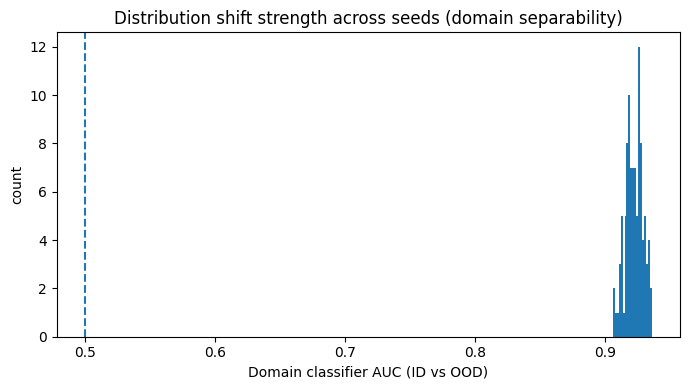

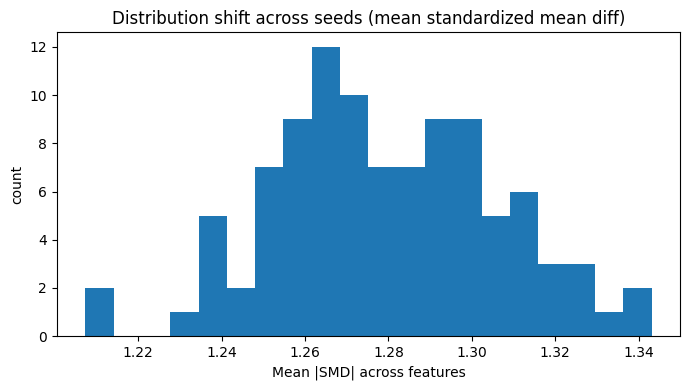

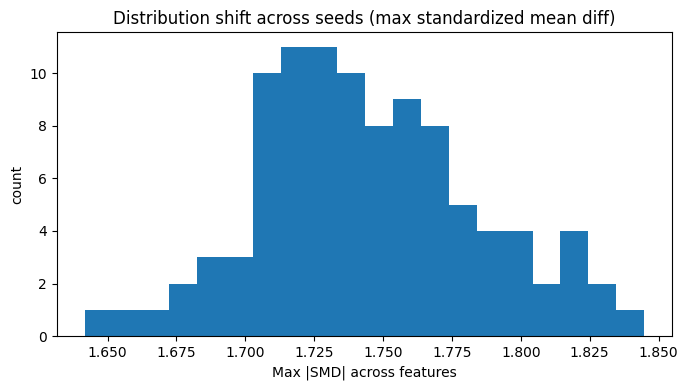

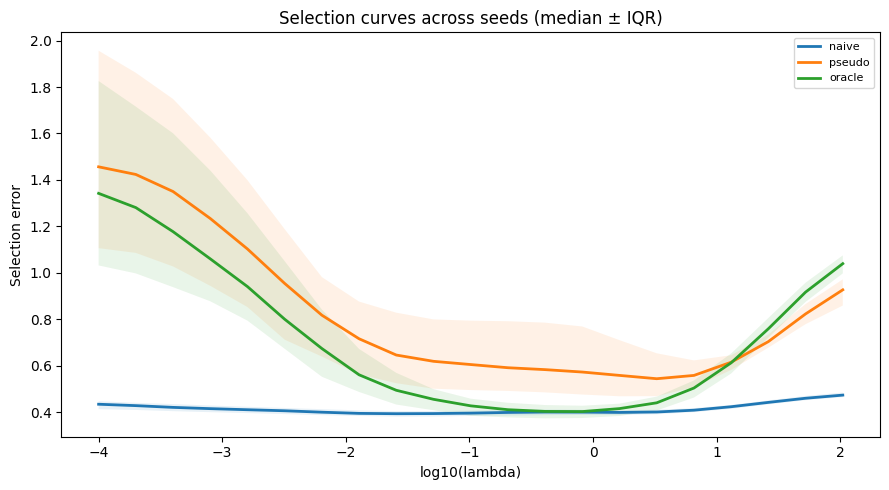

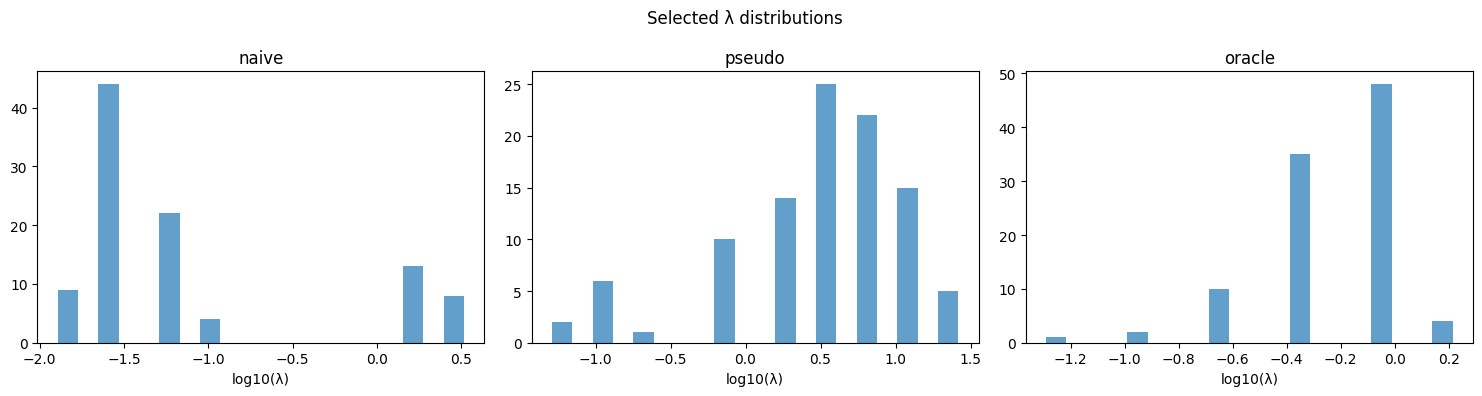


=== Per-method 'risk' across seeds: mean (95% CI) ===
            naive: 0.441671  CI[0.414386, 0.468955]  (SE=0.013751)
           pseudo: 0.382772  CI[0.371564, 0.393980]  (SE=0.005649)
           oracle: 0.375581  CI[0.362450, 0.388712]  (SE=0.006618)

=== risk: pseudo - naive ===
n_seeds = 100
mean(A-B) = -0.0588986   sd = 0.0990196   se = 0.00990196
95% t-CI for mean: [-0.0785462, -0.0392509]
t-test: t=-5.94817, p=2.04991e-08
Wilcoxon: W=575, p=9.38543e-10
Sign test: wins/losses/ties = 67/24/9  p=3.67427e-06
Bootstrap CI (mean): [-0.0788513, -0.0407421]  p=0

=== risk: oracle - naive ===
n_seeds = 100
mean(A-B) = -0.0660899   sd = 0.099291   se = 0.0099291
95% t-CI for mean: [-0.0857914, -0.0463884]
t-test: t=-6.65618, p=7.88506e-10
Wilcoxon: W=370, p=6.33452e-14
Sign test: wins/losses/ties = 84/16/0  p=1.30297e-12
Bootstrap CI (mean): [-0.0860373, -0.0478048]  p=0


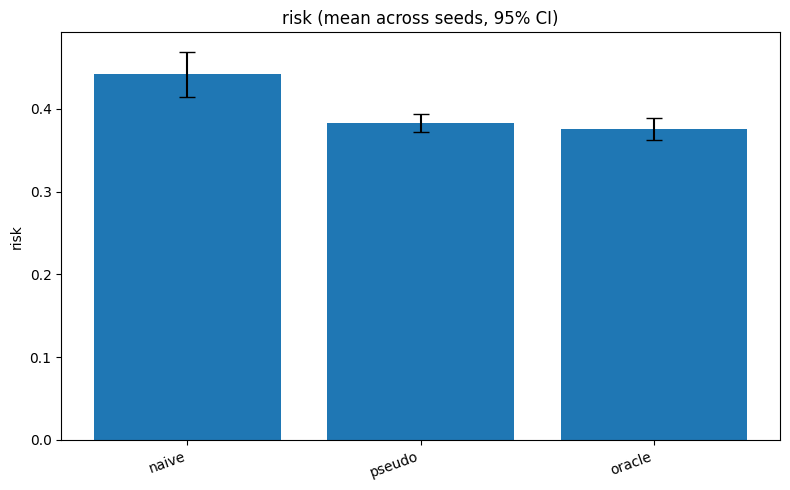

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_81805/3461227228.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


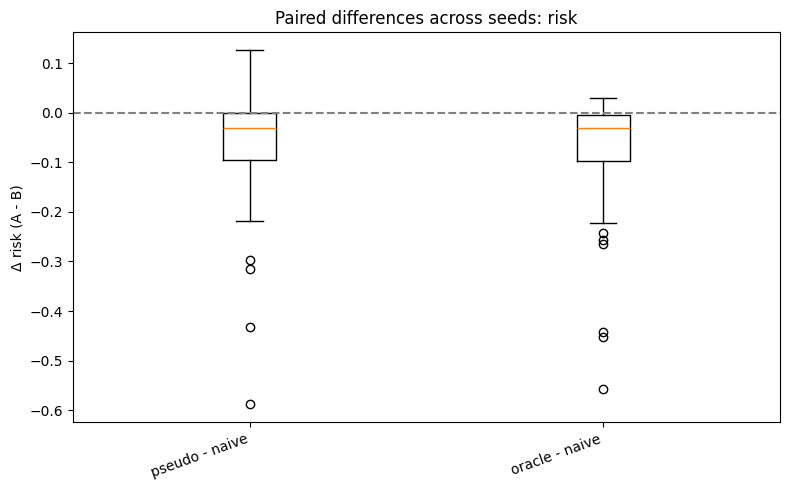


=== Per-method 'acc' across seeds: mean (95% CI) ===
            naive: 0.833468  CI[0.821300, 0.845636]  (SE=0.006132)
           pseudo: 0.852531  CI[0.845573, 0.859489]  (SE=0.003507)
           oracle: 0.859769  CI[0.854613, 0.864926]  (SE=0.002599)

=== acc: pseudo - naive ===
n_seeds = 100
mean(A-B) = 0.0190625   sd = 0.0412762   se = 0.00412762
95% t-CI for mean: [0.0108724, 0.0272526]
t-test: t=4.61828, p=5.82515e-06
Wilcoxon: W=2434.5, p=1.48266e-05
Sign test: wins/losses/ties = 54/25/21  p=0.000733036
Bootstrap CI (mean): [0.0112656, 0.0271975]  p=0

=== acc: oracle - naive ===
n_seeds = 100
mean(A-B) = 0.0263008   sd = 0.0482781   se = 0.00482781
95% t-CI for mean: [0.0167214, 0.0358803]
t-test: t=5.44778, p=1.86477e-07
Wilcoxon: W=3140.5, p=1.61127e-06
Sign test: wins/losses/ties = 56/33/11  p=0.0095933
Bootstrap CI (mean): [0.0171977, 0.0358602]  p=0


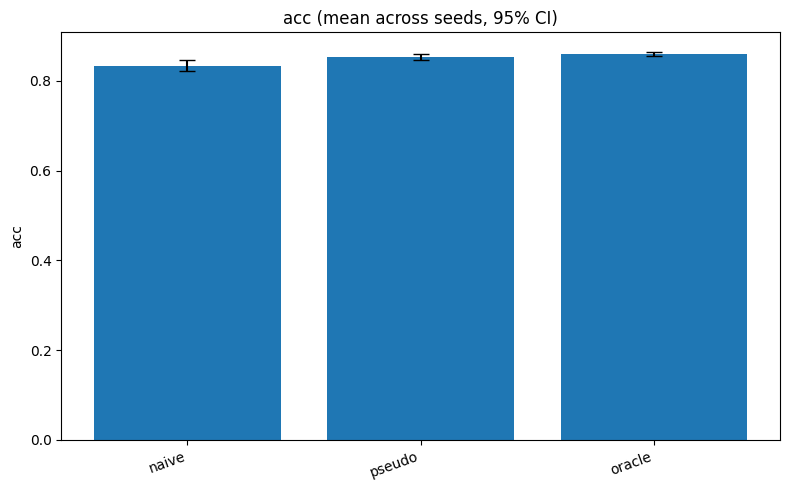

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_81805/3461227228.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


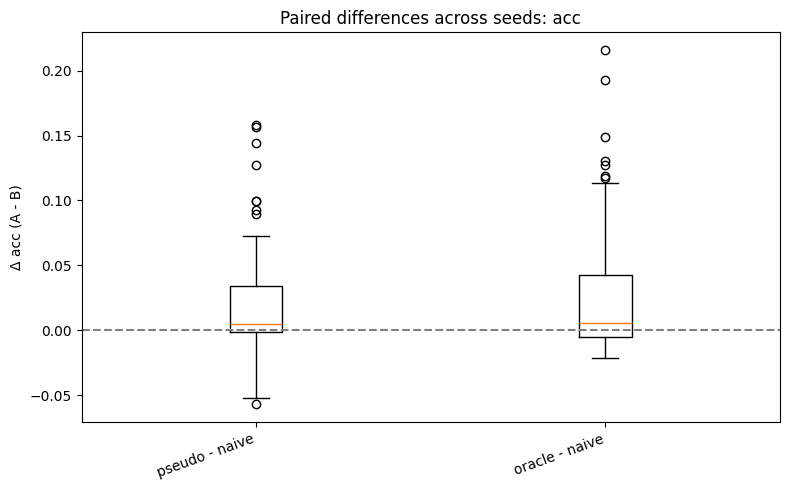


=== Per-method 'bal_acc' across seeds: mean (95% CI) ===
            naive: 0.836491  CI[0.828878, 0.844103]  (SE=0.003837)
           pseudo: 0.847464  CI[0.842467, 0.852461]  (SE=0.002518)
           oracle: 0.849436  CI[0.844619, 0.854254]  (SE=0.002428)

=== bal_acc: pseudo - naive ===
n_seeds = 100
mean(A-B) = 0.0109733   sd = 0.0325795   se = 0.00325795
95% t-CI for mean: [0.00450883, 0.0174378]
t-test: t=3.36816, p=0.000539556
Wilcoxon: W=2579, p=0.00488463
Sign test: wins/losses/ties = 50/38/12  p=0.120397
Bootstrap CI (mean): [0.00479887, 0.0173281]  p=5e-05

=== bal_acc: oracle - naive ===
n_seeds = 100
mean(A-B) = 0.0129458   sd = 0.035328   se = 0.0035328
95% t-CI for mean: [0.00593594, 0.0199556]
t-test: t=3.66445, p=0.000200283
Wilcoxon: W=2996, p=0.00732151
Sign test: wins/losses/ties = 52/44/4  p=0.237576
Bootstrap CI (mean): [0.00620097, 0.0198842]  p=0


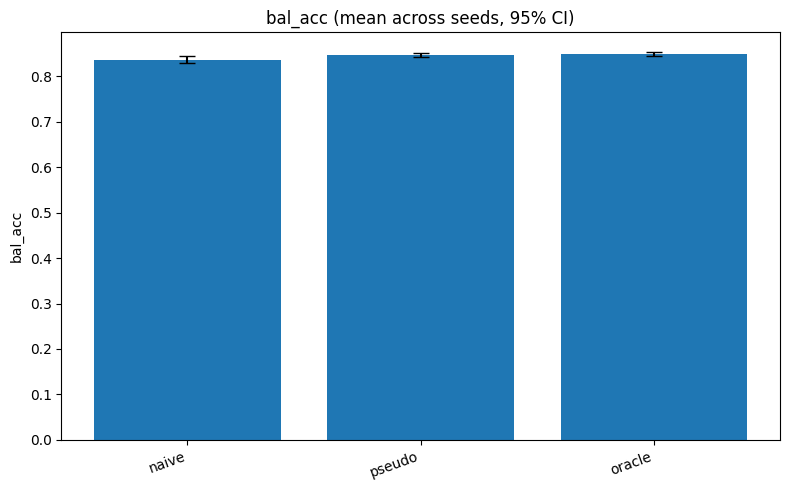

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_81805/3461227228.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


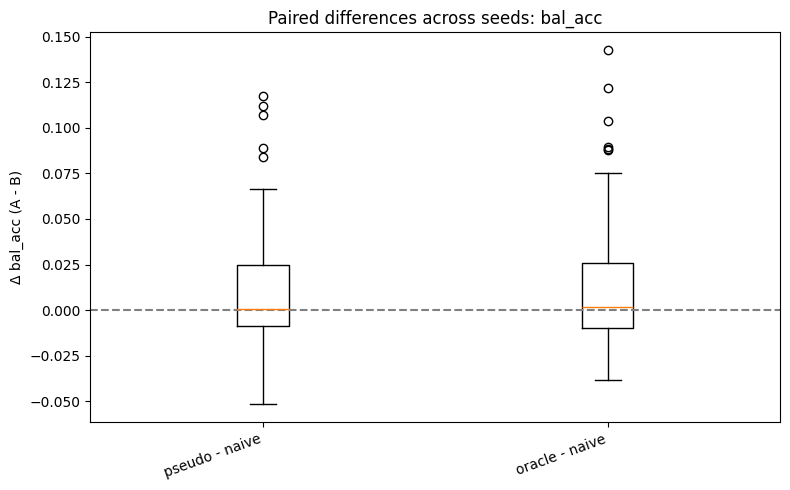


=== Best-in-grid regret on OOD_test (mean, 95% CI) ===
        regret_naive: 0.083715  CI[0.062509, 0.104921]  (SE=0.010687)
       regret_pseudo: 0.024816  CI[0.018937, 0.030696]  (SE=0.002963)
       regret_oracle: 0.017625  CI[0.013248, 0.022002]  (SE=0.002206)

Paired regret differences vs naive (lower is better):

=== regret: pseudo - naive ===
n_seeds = 100
mean(A-B) = -0.0588986   sd = 0.0990196   se = 0.00990196
95% t-CI for mean: [-0.0785462, -0.0392509]
t-test: t=-5.94817, p=2.04991e-08
Wilcoxon: W=575, p=9.38543e-10
Sign test: wins/losses/ties = 67/24/9  p=3.67427e-06
Bootstrap CI (mean): [-0.0788513, -0.0407421]  p=0

=== regret: oracle - naive ===
n_seeds = 100
mean(A-B) = -0.0660899   sd = 0.099291   se = 0.0099291
95% t-CI for mean: [-0.0857914, -0.0463884]
t-test: t=-6.65618, p=7.88506e-10
Wilcoxon: W=370, p=6.33452e-14
Sign test: wins/losses/ties = 84/16/0  p=1.30297e-12
Bootstrap CI (mean): [-0.0860373, -0.0478048]  p=0


In [27]:
seeds = [i + 100 for i in range(100)]

fit_kwargs_practical = dict(
    mode="practical",
    n_splits=5,
    repeats=2,
    beta=2.0,
    lbd_min=1e-4,
    lbd_max=100.0,
    lbd_tilde=1e-4,
    ood_test_frac=0.35,
    compute_auc=False,
    # optionally restrict methods, e.g. to skip slow KLIEP/KMM for a quick run:
    # methods=["naive", "pseudo", "oracle", "krr_pseudo", "krr_oracle", "kliep_iw", "kliep_oracle", "kmm_iw", "kmm_oracle"],
    methods=["naive", "pseudo", "oracle"],
)

results = paper_report_new(
    x_tot=x_tot, y_tot=y_tot,
    seeds=seeds,
    split_id_ood=split_id_ood,
    family="logistic",
    fit_kwargs=fit_kwargs_practical,
    alpha=0.05,
    B=20000,
)

Seeds: 100%|██████████| 100/100 [1:08:51<00:00, 41.32s/seed]


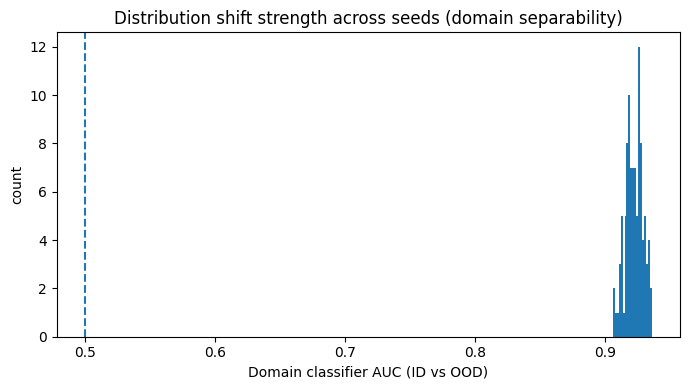

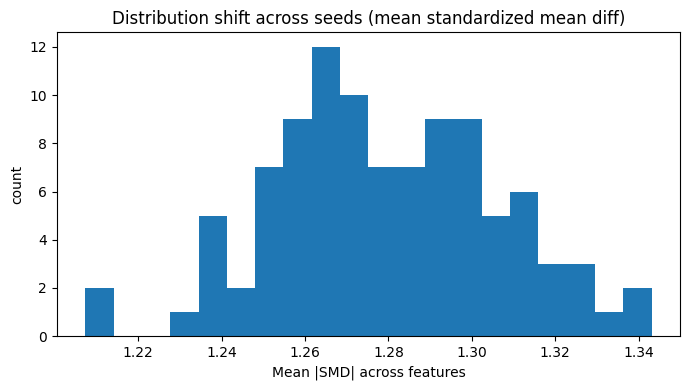

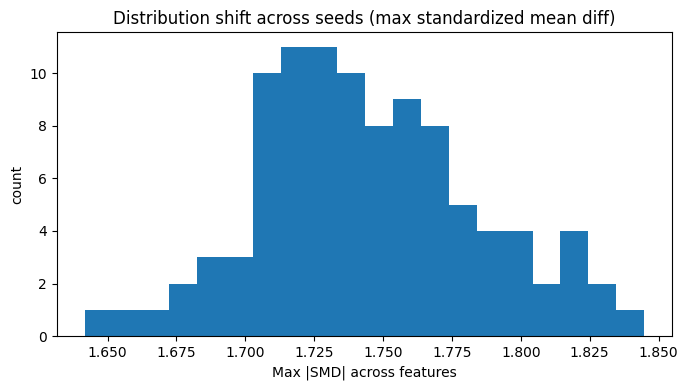

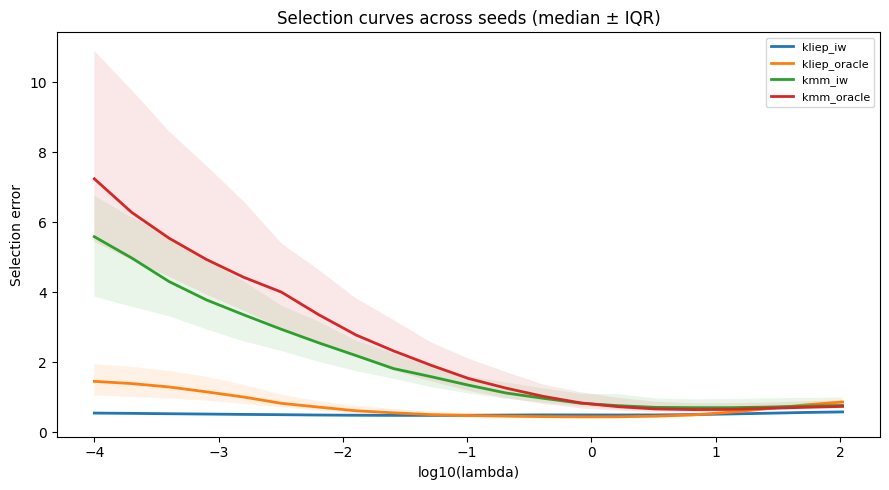

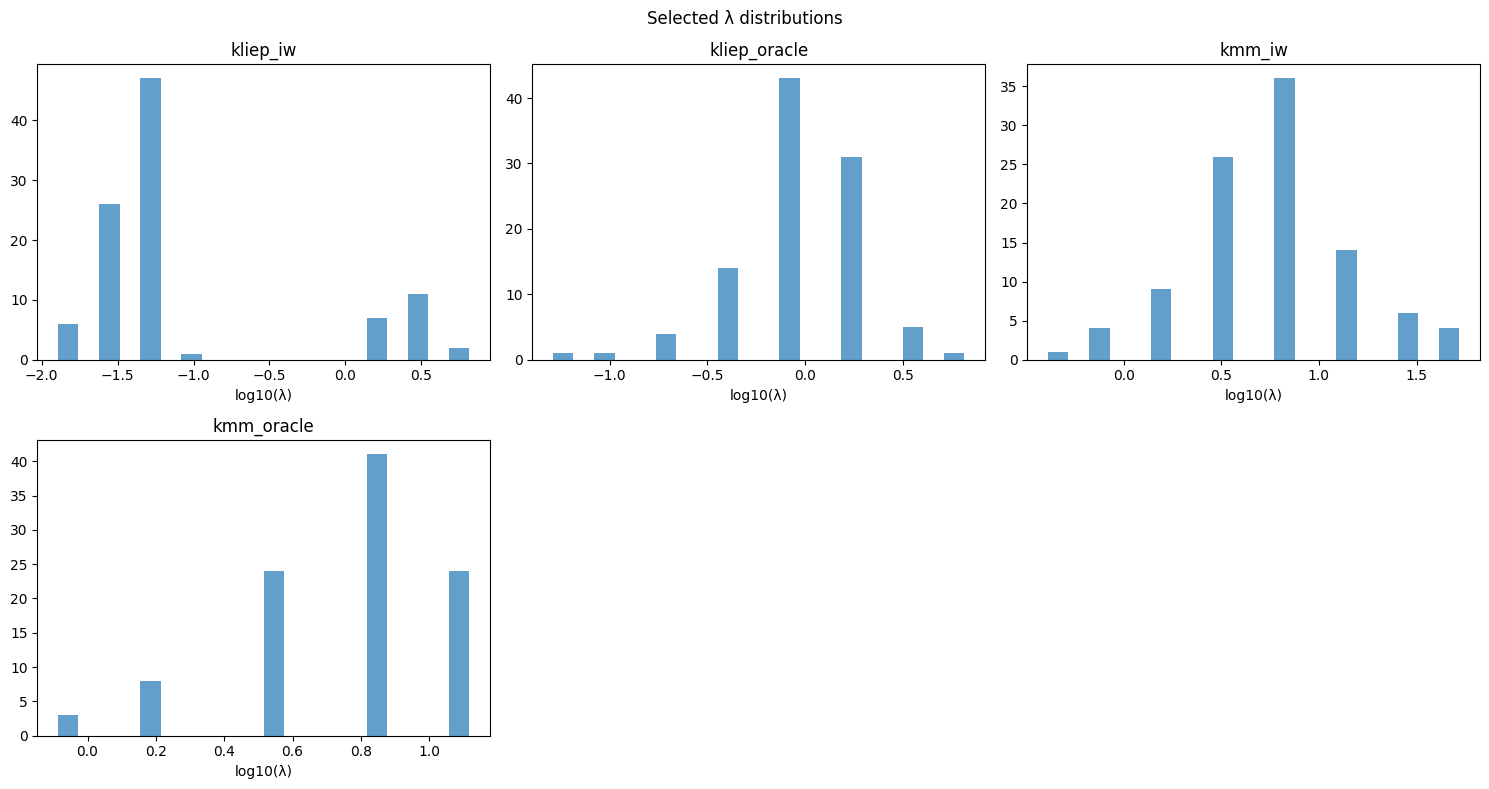


=== Per-method 'risk' across seeds: mean (95% CI) ===
         kliep_iw: 0.437969  CI[0.410919, 0.465020]  (SE=0.013633)
     kliep_oracle: 0.384290  CI[0.370378, 0.398203]  (SE=0.007012)
           kmm_iw: 0.449307  CI[0.430748, 0.467866]  (SE=0.009353)
       kmm_oracle: 0.436623  CI[0.420317, 0.452930]  (SE=0.008218)

=== risk: kliep_oracle - kliep_iw ===
n_seeds = 100
mean(A-B) = -0.0536789   sd = 0.0870442   se = 0.00870442
95% t-CI for mean: [-0.0709504, -0.0364075]
t-test: t=-6.16686, p=7.60881e-09
Wilcoxon: W=508, p=1.45707e-11
Sign test: wins/losses/ties = 76/20/4  p=3.65968e-09
Bootstrap CI (mean): [-0.0712911, -0.0379761]  p=0

=== risk: kmm_iw - kliep_iw ===
n_seeds = 100
mean(A-B) = 0.0113378   sd = 0.125201   se = 0.0125201
95% t-CI for mean: [-0.0135048, 0.0361805]
t-test: t=0.905568, p=0.816318
Wilcoxon: W=2909, p=0.906635
Sign test: wins/losses/ties = 41/59/0  p=0.971556
Bootstrap CI (mean): [-0.0131361, 0.0359506]  p=0.8211

=== risk: kmm_oracle - kliep_iw ===
n_seed

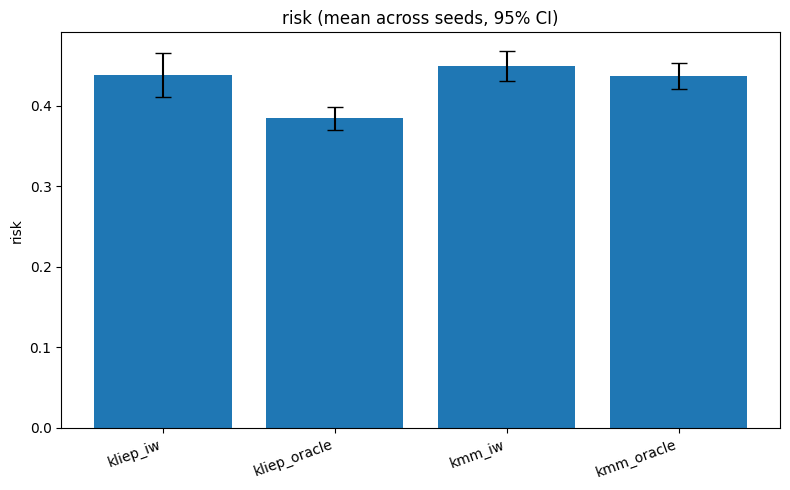

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_84444/2574619089.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


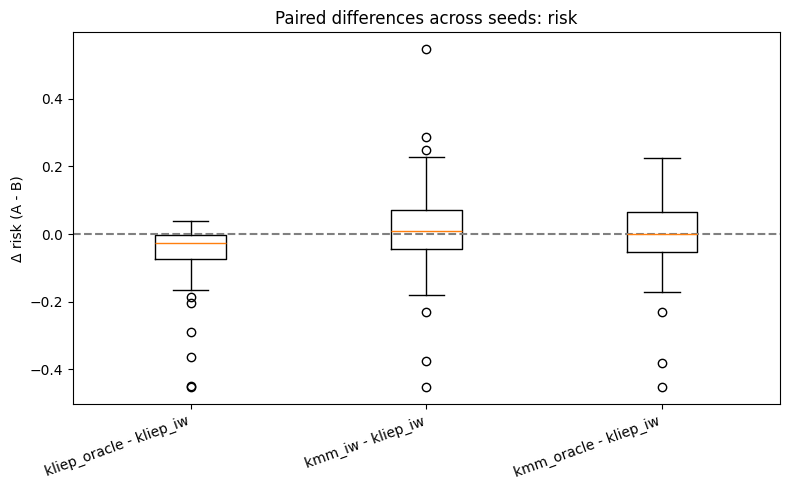


=== Per-method 'acc' across seeds: mean (95% CI) ===
         kliep_iw: 0.836940  CI[0.826240, 0.847641]  (SE=0.005393)
     kliep_oracle: 0.855864  CI[0.849813, 0.861914]  (SE=0.003049)
           kmm_iw: 0.817967  CI[0.809512, 0.826421]  (SE=0.004261)
       kmm_oracle: 0.818784  CI[0.809224, 0.828344]  (SE=0.004818)

=== acc: kliep_oracle - kliep_iw ===
n_seeds = 100
mean(A-B) = 0.0189232   sd = 0.0363783   se = 0.00363783
95% t-CI for mean: [0.0117049, 0.0261414]
t-test: t=5.20177, p=5.33629e-07
Wilcoxon: W=3027, p=1.23362e-06
Sign test: wins/losses/ties = 61/26/13  p=0.000111845
Bootstrap CI (mean): [0.0120945, 0.0262149]  p=0

=== acc: kmm_iw - kliep_iw ===
n_seeds = 100
mean(A-B) = -0.0189739   sd = 0.0452913   se = 0.00452913
95% t-CI for mean: [-0.0279607, -0.00998716]
t-test: t=-4.18931, p=0.99997
Wilcoxon: W=1165, p=0.999983
Sign test: wins/losses/ties = 27/68/5  p=0.999994
Bootstrap CI (mean): [-0.0277624, -0.00995367]  p=1

=== acc: kmm_oracle - kliep_iw ===
n_seeds = 100

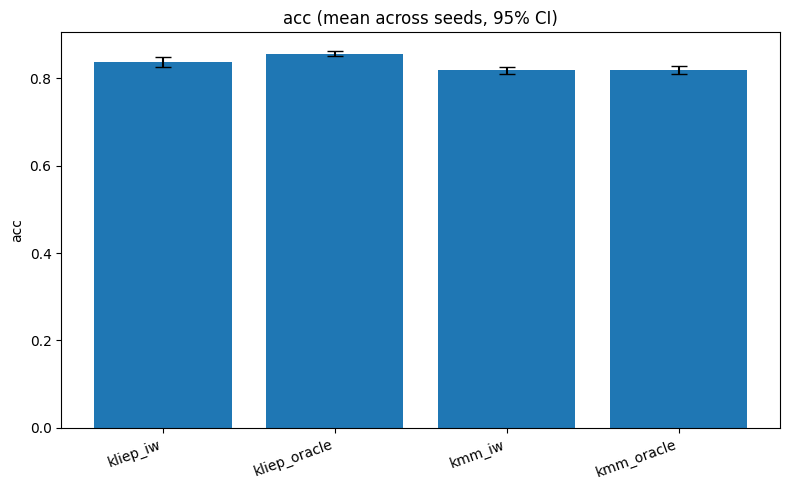

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_84444/2574619089.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


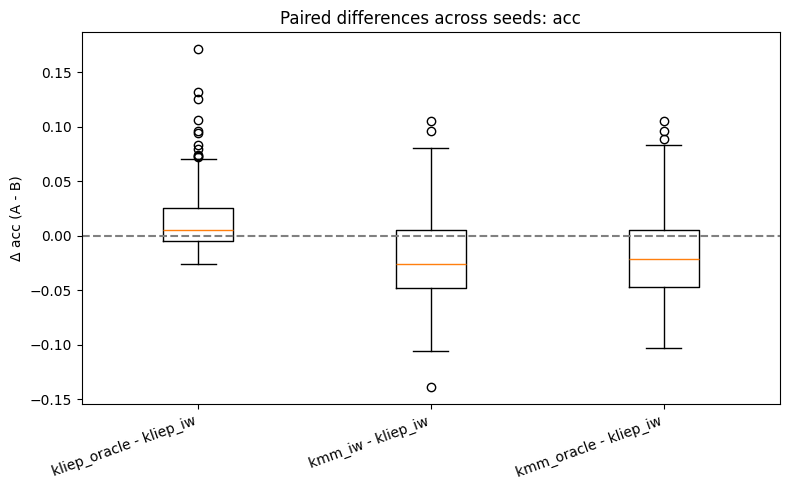


=== Per-method 'bal_acc' across seeds: mean (95% CI) ===
         kliep_iw: 0.837295  CI[0.830644, 0.843945]  (SE=0.003352)
     kliep_oracle: 0.847284  CI[0.842029, 0.852539]  (SE=0.002648)
           kmm_iw: 0.802821  CI[0.794762, 0.810880]  (SE=0.004062)
       kmm_oracle: 0.804157  CI[0.795670, 0.812643]  (SE=0.004277)

=== bal_acc: kliep_oracle - kliep_iw ===
n_seeds = 100
mean(A-B) = 0.00998928   sd = 0.0278502   se = 0.00278502
95% t-CI for mean: [0.0044632, 0.0155154]
t-test: t=3.58679, p=0.000261074
Wilcoxon: W=2818.5, p=0.00204286
Sign test: wins/losses/ties = 51/40/9  p=0.147235
Bootstrap CI (mean): [0.00468231, 0.0155412]  p=5e-05

=== bal_acc: kmm_iw - kliep_iw ===
n_seeds = 100
mean(A-B) = -0.0344738   sd = 0.0441116   se = 0.00441116
95% t-CI for mean: [-0.0432265, -0.0257211]
t-test: t=-7.81512, p=1
Wilcoxon: W=702, p=1
Sign test: wins/losses/ties = 21/79/0  p=1
Bootstrap CI (mean): [-0.0430123, -0.0257578]  p=1

=== bal_acc: kmm_oracle - kliep_iw ===
n_seeds = 100
mea

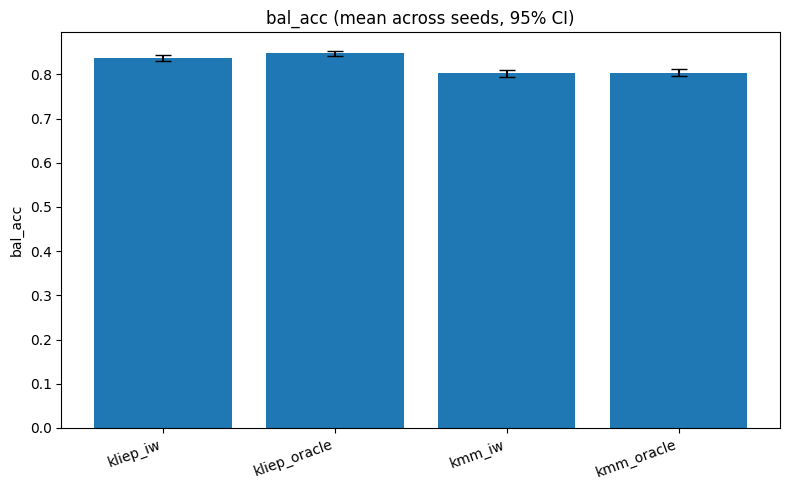

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_84444/2574619089.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


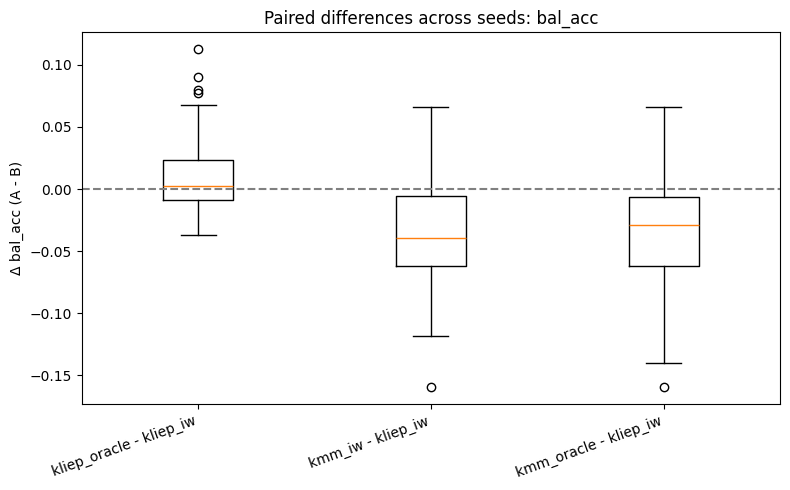


=== Best-in-grid regret on OOD_test (mean, 95% CI) ===
     regret_kliep_iw: 0.073836  CI[0.055563, 0.092110]  (SE=0.009210)
 regret_kliep_oracle: 0.020157  CI[0.015429, 0.024885]  (SE=0.002383)
       regret_kmm_iw: 0.027807  CI[0.019612, 0.036001]  (SE=0.004130)
   regret_kmm_oracle: 0.022675  CI[0.017435, 0.027916]  (SE=0.002641)

Paired regret differences vs kliep_iw (lower is better):

=== regret: kliep_oracle - kliep_iw ===
n_seeds = 100
mean(A-B) = -0.0536789   sd = 0.0870442   se = 0.00870442
95% t-CI for mean: [-0.0709504, -0.0364075]
t-test: t=-6.16686, p=7.60881e-09
Wilcoxon: W=508, p=1.45707e-11
Sign test: wins/losses/ties = 76/20/4  p=3.65968e-09
Bootstrap CI (mean): [-0.0712911, -0.0379761]  p=0

=== regret: kmm_iw - kliep_iw ===
n_seeds = 100
mean(A-B) = -0.0460295   sd = 0.110291   se = 0.0110291
95% t-CI for mean: [-0.0679137, -0.0241453]
t-test: t=-4.17345, p=3.22678e-05
Wilcoxon: W=1351, p=2.71165e-05
Sign test: wins/losses/ties = 67/33/0  p=0.00043686
Bootstrap CI 

In [10]:
seeds = [i + 100 for i in range(100)]

fit_kwargs_practical = dict(
    mode="practical",
    n_splits=5,
    repeats=2,
    beta=2.0,
    lbd_min=1e-4,
    lbd_max=100.0,
    lbd_tilde=1e-4,
    ood_test_frac=0.35,
    compute_auc=False,
    # optionally restrict methods, e.g. to skip slow KLIEP/KMM for a quick run:
    # methods=["naive", "pseudo", "oracle", "krr_pseudo", "krr_oracle", "kliep_iw", "kliep_oracle", "kmm_iw", "kmm_oracle"],
    methods=["kliep_iw", "kliep_oracle", "kmm_iw", "kmm_oracle"],
)

results = paper_report_new(
    x_tot=x_tot, y_tot=y_tot,
    seeds=seeds,
    split_id_ood=split_id_ood,
    family="logistic",
    fit_kwargs=fit_kwargs_practical,
    alpha=0.05,
    B=20000,
)

Seeds: 100%|██████████| 100/100 [00:48<00:00,  2.07seed/s]


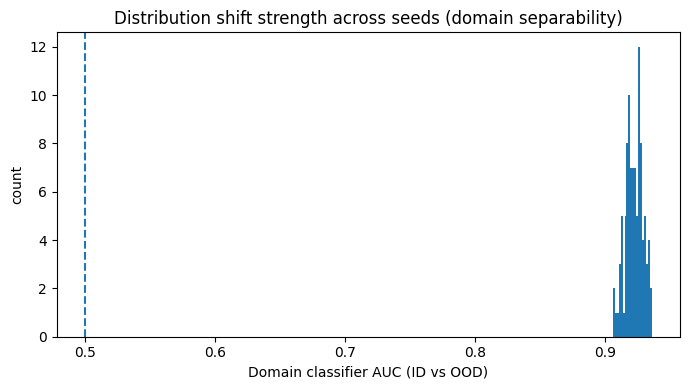

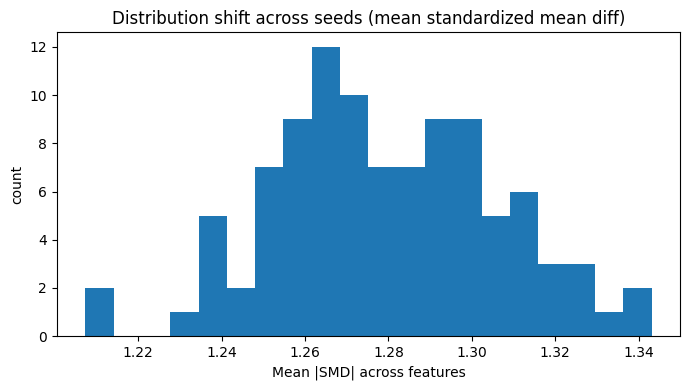

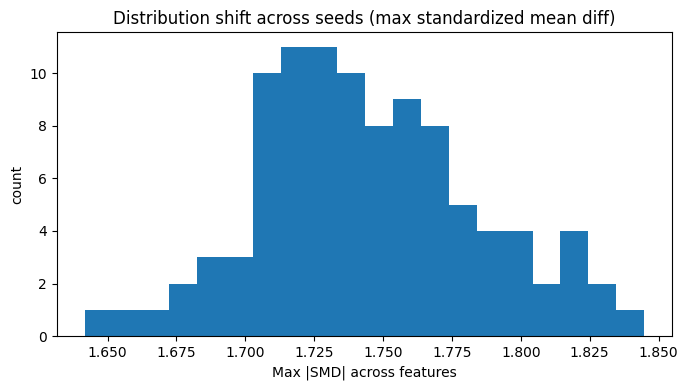

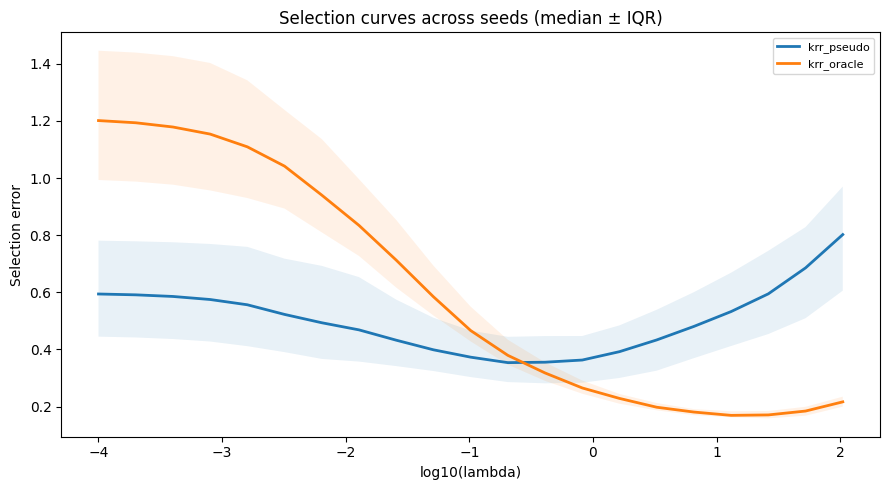

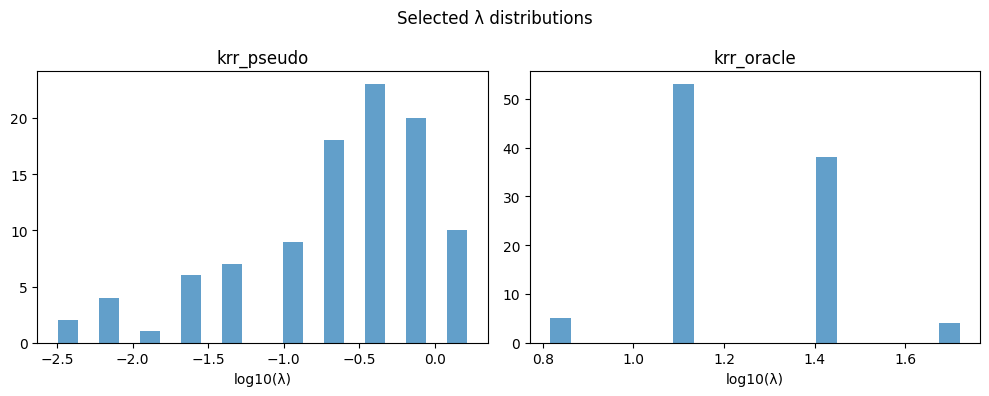


=== Per-method 'risk' across seeds: mean (95% CI) ===
       krr_pseudo: 0.405945  CI[0.387761, 0.424129]  (SE=0.009164)
       krr_oracle: 0.443463  CI[0.430115, 0.456812]  (SE=0.006727)

=== risk: krr_oracle - krr_pseudo ===
n_seeds = 100
mean(A-B) = 0.0375182   sd = 0.0435591   se = 0.00435591
95% t-CI for mean: [0.0288751, 0.0461613]
t-test: t=8.61317, p=1
Wilcoxon: W=4529, p=1
Sign test: wins/losses/ties = 21/79/0  p=1
Bootstrap CI (mean): [0.0288711, 0.0458171]  p=1


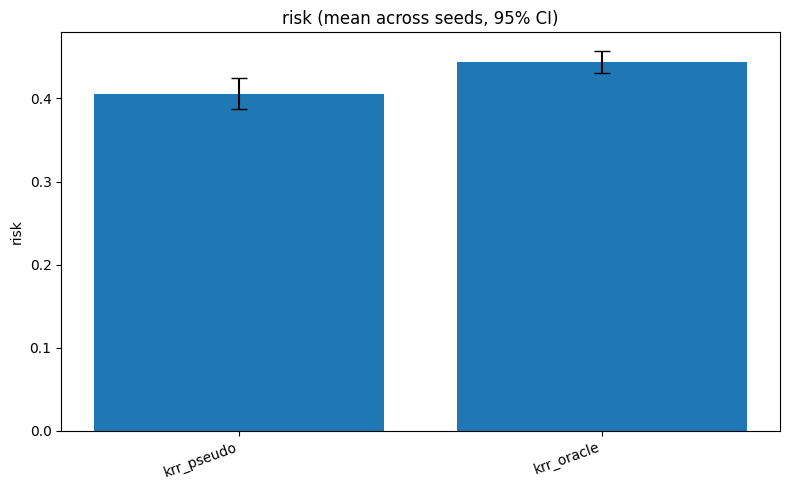

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_84444/2574619089.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


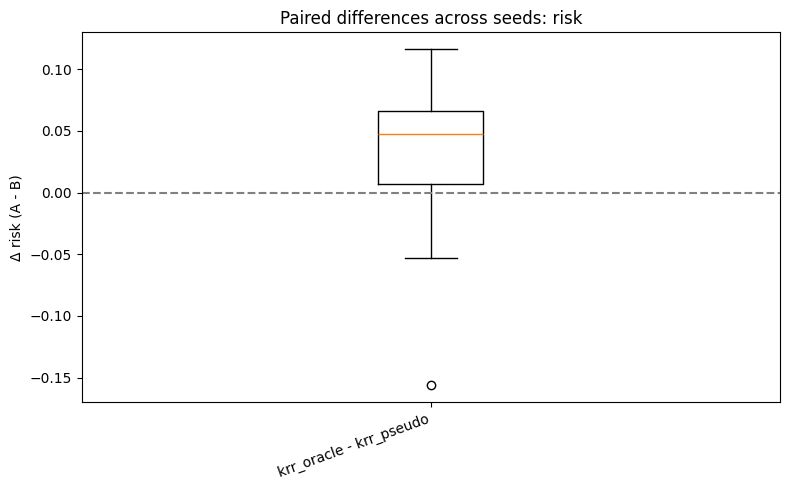


=== Per-method 'acc' across seeds: mean (95% CI) ===
       krr_pseudo: 0.843606  CI[0.834982, 0.852230]  (SE=0.004346)
       krr_oracle: 0.833946  CI[0.826197, 0.841696]  (SE=0.003905)

=== acc: krr_oracle - krr_pseudo ===
n_seeds = 100
mean(A-B) = -0.00965992   sd = 0.0301431   se = 0.00301431
95% t-CI for mean: [-0.015641, -0.00367887]
t-test: t=-3.20468, p=0.99909
Wilcoxon: W=1287.5, p=0.999284
Sign test: wins/losses/ties = 30/61/9  p=0.999647
Bootstrap CI (mean): [-0.0156274, -0.00380703]  p=0.99965


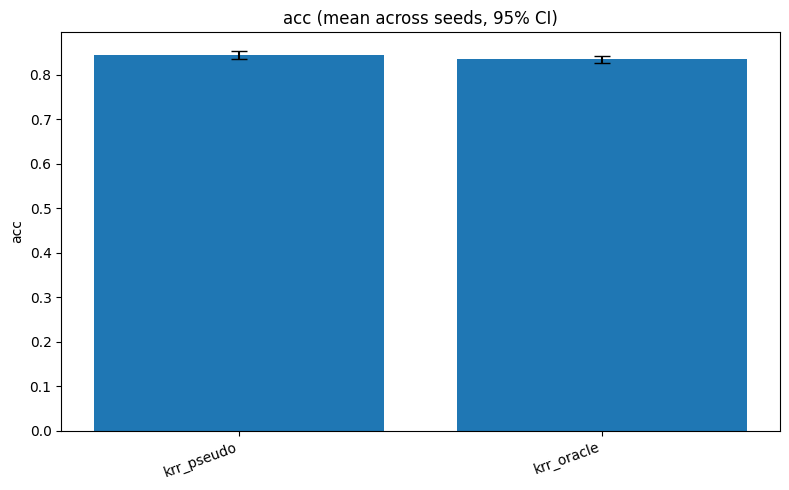

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_84444/2574619089.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


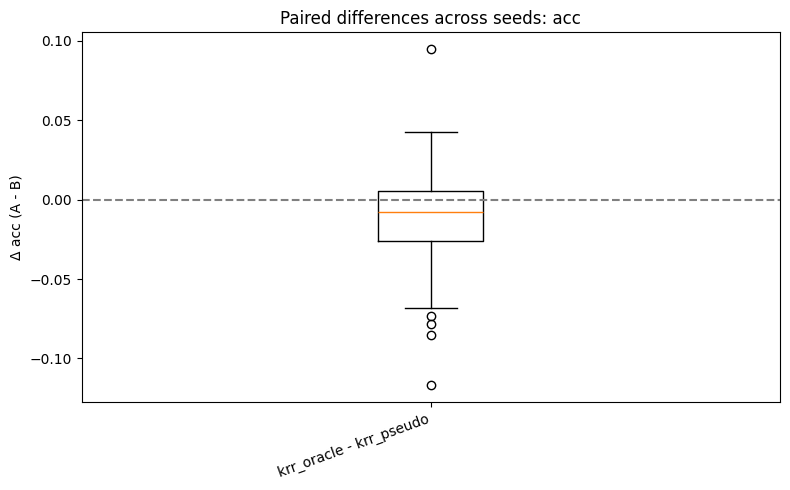


=== Per-method 'bal_acc' across seeds: mean (95% CI) ===
       krr_pseudo: 0.852475  CI[0.847016, 0.857934]  (SE=0.002751)
       krr_oracle: 0.853447  CI[0.848258, 0.858635]  (SE=0.002615)

=== bal_acc: krr_oracle - krr_pseudo ===
n_seeds = 100
mean(A-B) = 0.000971911   sd = 0.0234441   se = 0.00234441
95% t-CI for mean: [-0.0036799, 0.00562372]
t-test: t=0.414566, p=0.339678
Wilcoxon: W=2681.5, p=0.295254
Sign test: wins/losses/ties = 54/46/0  p=0.242059
Bootstrap CI (mean): [-0.0036848, 0.00549839]  p=0.3414


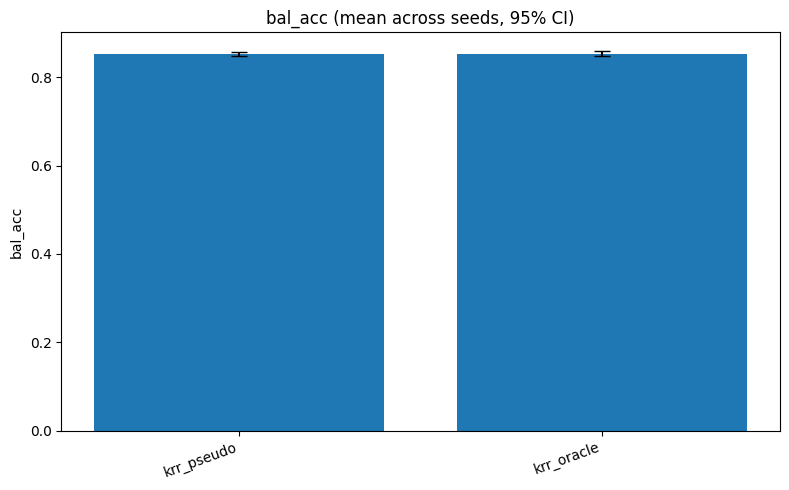

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_84444/2574619089.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, showfliers=True)


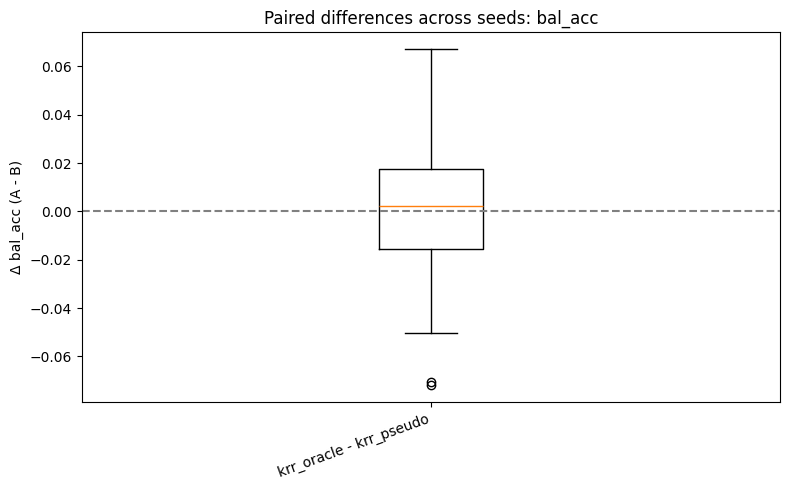


=== Best-in-grid regret on OOD_test (mean, 95% CI) ===
   regret_krr_pseudo: 0.027027  CI[0.022166, 0.031887]  (SE=0.002450)
   regret_krr_oracle: 0.064545  CI[0.058603, 0.070487]  (SE=0.002995)

Paired regret differences vs krr_pseudo (lower is better):

=== regret: krr_oracle - krr_pseudo ===
n_seeds = 100
mean(A-B) = 0.0375182   sd = 0.0435591   se = 0.00435591
95% t-CI for mean: [0.0288751, 0.0461613]
t-test: t=8.61317, p=1
Wilcoxon: W=4529, p=1
Sign test: wins/losses/ties = 21/79/0  p=1
Bootstrap CI (mean): [0.0288711, 0.0458171]  p=1


In [11]:
seeds = [i + 100 for i in range(100)]

fit_kwargs_practical = dict(
    mode="practical",
    n_splits=5,
    repeats=2,
    beta=2.0,
    lbd_min=1e-4,
    lbd_max=100.0,
    lbd_tilde=1e-4,
    ood_test_frac=0.35,
    compute_auc=False,
    # optionally restrict methods, e.g. to skip slow KLIEP/KMM for a quick run:
    # methods=["naive", "pseudo", "oracle", "krr_pseudo", "krr_oracle", "kliep_iw", "kliep_oracle", "kmm_iw", "kmm_oracle"],
    methods=["krr_pseudo", "krr_oracle"],
)

results = paper_report_new(
    x_tot=x_tot, y_tot=y_tot,
    seeds=seeds,
    split_id_ood=split_id_ood,
    family="logistic",
    fit_kwargs=fit_kwargs_practical,
    alpha=0.05,
    B=20000,
)